# Comprehensive vLLM Benchmark & Quality Evaluation Analysis

**Date:** March 2026  
**Models:** DeepSeek-R1-Distill-Qwen-7B (reasoning) · Qwen2.5-7B-Instruct (non-reasoning)  
**GPU:** NVIDIA L4 (24 GB) on Lightning.ai  
**Engine:** vLLM v0.16+ (V1 engine) · max-model-len 4096 · tensor-parallel 1  
**Load generator:** Locust (streaming SSE) · 90 s per sub-test  

## Three Benchmark Runs

| Run | ID | Model | Experiments | Purpose |
|-----|----|-------|-------------|---------|
| **Quantization (Reasoning)** | `run_20260326_115430` | DeepSeek-R1 | baseline, fp8, bitsandbytes | Quantization impact on reasoning model |
| **Quantization (Non-Reasoning)** | `run_20260326_203057` | Qwen2.5 | baseline, fp8, bitsandbytes | Quantization impact on non-reasoning model |
| **I/O Profiles** | `run_20260327_010556` | DeepSeek-R1 | 6 prompt profiles | How prompt type affects latency |

## Quality Evaluation (lm-evaluation-harness)

| Model | Quantizations | Benchmarks |
|-------|---------------|------------|
| DeepSeek-R1-Distill-Qwen-7B | none, fp8, bitsandbytes | ARC-Challenge, MMLU, GSM8K |
| Qwen2.5-7B-Instruct | none, fp8, bitsandbytes | ARC-Challenge, MMLU, GSM8K |

In [1]:
import glob, json, os, textwrap, warnings, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.titlesize': 14,
})

# ─── Configuration ────────────────────────────────────────────────────────────
RESULTS_ROOT  = Path('results')
EVAL_ROOT     = Path('../evaluation/results')

RUN_QUANT_REASONING    = 'run_20260326_115430'   # DeepSeek-R1: baseline / fp8 / bnb
RUN_QUANT_NONREASONING = 'run_20260326_203057'   # Qwen2.5:    baseline / fp8 / bnb
RUN_IO_PROFILES        = 'run_20260327_010556'   # DeepSeek-R1: 6 prompt profiles

GPU_HOURLY_COST_USD = 1.58  # Lightning.ai L4
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
# ─── Helper: load Locust custom-metrics CSVs from a run ──────────────────────
def _extract_users(filename: str) -> int:
    """Extract user count from filename like 'baseline__u16_custom_metrics'."""
    m = re.search(r'_u(\d+)', filename)
    return int(m.group(1)) if m else 0

def load_run_locust(run_dir: Path, run_label: str) -> pd.DataFrame:
    """Return a DataFrame with all custom_metrics rows, tagged with experiment / users / run."""
    frames = []
    for csv_path in sorted(run_dir.rglob('*custom_metrics*.csv')):
        exp     = csv_path.parent.name
        users   = _extract_users(csv_path.stem)
        df = pd.read_csv(csv_path)
        df['experiment'] = exp
        df['users']      = users
        df['run']        = run_label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# ─── Helper: load Prometheus metrics from a run ──────────────────────────────
def load_prometheus(run_dir: Path, run_label: str) -> pd.DataFrame:
    frames = []
    for csv_path in sorted(run_dir.rglob('*prometheus_metrics*.csv')):
        exp     = csv_path.parent.name
        users   = _extract_users(csv_path.stem)
        try:
            df = pd.read_csv(csv_path)
            df['experiment'] = exp
            df['users']      = users
            df['run']        = run_label
            df['timestamp']  = pd.to_numeric(df['timestamp'], errors='coerce')
            df['value']      = pd.to_numeric(df['value'], errors='coerce')
            frames.append(df)
        except Exception as e:
            print(f'⚠ {csv_path.name}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# ─── Helper: load evaluation results ─────────────────────────────────────────
def load_evaluations(eval_root: Path) -> pd.DataFrame:
    rows = []
    for result_json in sorted(eval_root.rglob('results_*.json')):
        folder_name = result_json.parent.parent.name  # e.g. deepseek-r1-fp8-arc_challenge
        data = json.loads(result_json.read_text(encoding='utf-8'))

        # Parse folder name: model-quant-benchmark
        # Patterns: deepseek-r1-{quant}-{benchmark} or qwen-2.5-{quant}-{benchmark}
        if folder_name.startswith('deepseek-r1-'):
            model = 'DeepSeek-R1'
            rest  = folder_name[len('deepseek-r1-'):]
        elif folder_name.startswith('qwen-2.5-'):
            model = 'Qwen2.5'
            rest  = folder_name[len('qwen-2.5-'):]
        else:
            continue

        # Split rest into quant and benchmark
        for quant in ['noquantization', 'bitsandbytes', 'fp8']:
            if rest.startswith(quant + '-'):
                benchmark = rest[len(quant) + 1:]
                break
        else:
            continue

        results = data.get('results', {})
        for task_name, task_results in results.items():
            row = {
                'model': model,
                'quantization': quant,
                'benchmark': benchmark,
                'task': task_name,
                'folder': folder_name,
            }
            # Extract all metric values
            for key, val in task_results.items():
                if ',' in key:  # metric keys like 'acc,none'
                    metric_name = key.split(',')[0]
                    row[metric_name] = val
            rows.append(row)
    return pd.DataFrame(rows)

In [3]:
# ─── Load all benchmark data ─────────────────────────────────────────────────
dir_quant_r  = RESULTS_ROOT / RUN_QUANT_REASONING
dir_quant_nr = RESULTS_ROOT / RUN_QUANT_NONREASONING
dir_io       = RESULTS_ROOT / RUN_IO_PROFILES

df_quant_r  = load_run_locust(dir_quant_r,  'quant_reasoning')
df_quant_nr = load_run_locust(dir_quant_nr, 'quant_nonreasoning')
df_io       = load_run_locust(dir_io,       'io_profiles')

# Also load prometheus data
prom_quant_r  = load_prometheus(dir_quant_r,  'quant_reasoning')
prom_quant_nr = load_prometheus(dir_quant_nr, 'quant_nonreasoning')
prom_io       = load_prometheus(dir_io,       'io_profiles')

# Load config descriptions
desc_map = {}
for cfg in RESULTS_ROOT.rglob('config.json'):
    try:
        c = json.loads(cfg.read_text())
        desc_map[c['name']] = c.get('description', '')
    except Exception:
        pass

# Load evaluation data
df_eval = load_evaluations(EVAL_ROOT)

print('─── Benchmark Data ───')
for label, df in [('Quant Reasoning', df_quant_r), ('Quant Non-Reasoning', df_quant_nr), ('I/O Profiles', df_io)]:
    ok = len(df[df['success'] == True]) if 'success' in df.columns else 0
    print(f'  {label:25s}: {len(df):>5,} rows  |  {df["experiment"].nunique()} experiments  |  {ok} successful')

print(f'\n─── Prometheus Metrics ───')
for label, df in [('Quant Reasoning', prom_quant_r), ('Quant Non-Reasoning', prom_quant_nr), ('I/O Profiles', prom_io)]:
    print(f'  {label:25s}: {len(df):>5,} rows' if not df.empty else f'  {label:25s}: empty')

print(f'\n─── Quality Evaluation ───')
print(f'  {len(df_eval)} task-level results across {df_eval["folder"].nunique()} evaluation runs')

─── Benchmark Data ───
  Quant Reasoning          :   419 rows  |  3 experiments  |  419 successful
  Quant Non-Reasoning      :   384 rows  |  2 experiments  |  384 successful
  I/O Profiles             : 1,238 rows  |  6 experiments  |  1238 successful

─── Prometheus Metrics ───
  Quant Reasoning          : 23,311 rows
  Quant Non-Reasoning      : 16,032 rows
  I/O Profiles             : 49,949 rows

─── Quality Evaluation ───
  321 task-level results across 16 evaluation runs


In [4]:
# ─── Percentile summary builder ──────────────────────────────────────────────
def pct(s, p):
    return s.quantile(p / 100)

def build_summary(df):
    ok = df[df['success'] == True].copy()
    if ok.empty:
        return pd.DataFrame()
    return (
        ok.groupby(['experiment', 'users'])
        .agg(
            n             = ('ttft_ms', 'count'),
            ttft_mean     = ('ttft_ms', 'mean'),
            ttft_p50      = ('ttft_ms', lambda s: pct(s, 50)),
            ttft_p95      = ('ttft_ms', lambda s: pct(s, 95)),
            ttft_p99      = ('ttft_ms', lambda s: pct(s, 99)),
            tpot_mean     = ('tpot_ms', 'mean'),
            tpot_p50      = ('tpot_ms', lambda s: pct(s, 50)),
            tpot_p99      = ('tpot_ms', lambda s: pct(s, 99)),
            e2e_mean      = ('e2e_ms', 'mean'),
            e2e_p50       = ('e2e_ms', lambda s: pct(s, 50)),
            e2e_p99       = ('e2e_ms', lambda s: pct(s, 99)),
            itl_p50_mean  = ('itl_p50_ms', 'mean'),
            itl_p99_mean  = ('itl_p99_ms', 'mean'),
            output_tokens = ('output_tokens', 'sum'),
        )
        .reset_index()
    )

sum_qr  = build_summary(df_quant_r)
sum_qnr = build_summary(df_quant_nr)
sum_io  = build_summary(df_io)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

---
# Part 1 — Quantization Impact: Reasoning Model (DeepSeek-R1)

Comparing **baseline (FP16)** vs **FP8** vs **BitsAndBytes** on DeepSeek-R1-Distill-Qwen-7B.  
Note: BitsAndBytes only has u16 data (u64 failed to collect).

In [5]:
# ─── Summary table: Quantization on Reasoning Model ─────────────────────────
print('Quantization Comparison — DeepSeek-R1 (Reasoning):')
display(sum_qr)

Quantization Comparison — DeepSeek-R1 (Reasoning):


,experiment,users,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,baseline,16,47,627.9,468.0,880.6,4210.3,69.3,69.0,78.0,86813.3,71381.8,236252.3,64.9,131.7,58852
1,baseline,64,121,9966.2,758.6,39065.1,49568.4,112.1,111.1,175.9,151936.2,151674.7,285917.0,90.8,663.0,155832
2,bitsandbytes_quantization,16,18,1051.6,689.3,4080.3,4206.0,137.8,137.9,142.6,203806.4,200770.2,305464.3,132.7,168.4,26539
3,fp8_quantization,16,65,436.3,338.4,557.3,4211.2,45.0,44.7,50.9,49071.1,46502.9,119676.4,41.5,87.6,70378
4,fp8_quantization,64,168,454.3,436.4,764.5,1034.1,74.7,76.3,86.8,99269.4,98972.9,250511.5,64.5,425.2,225133


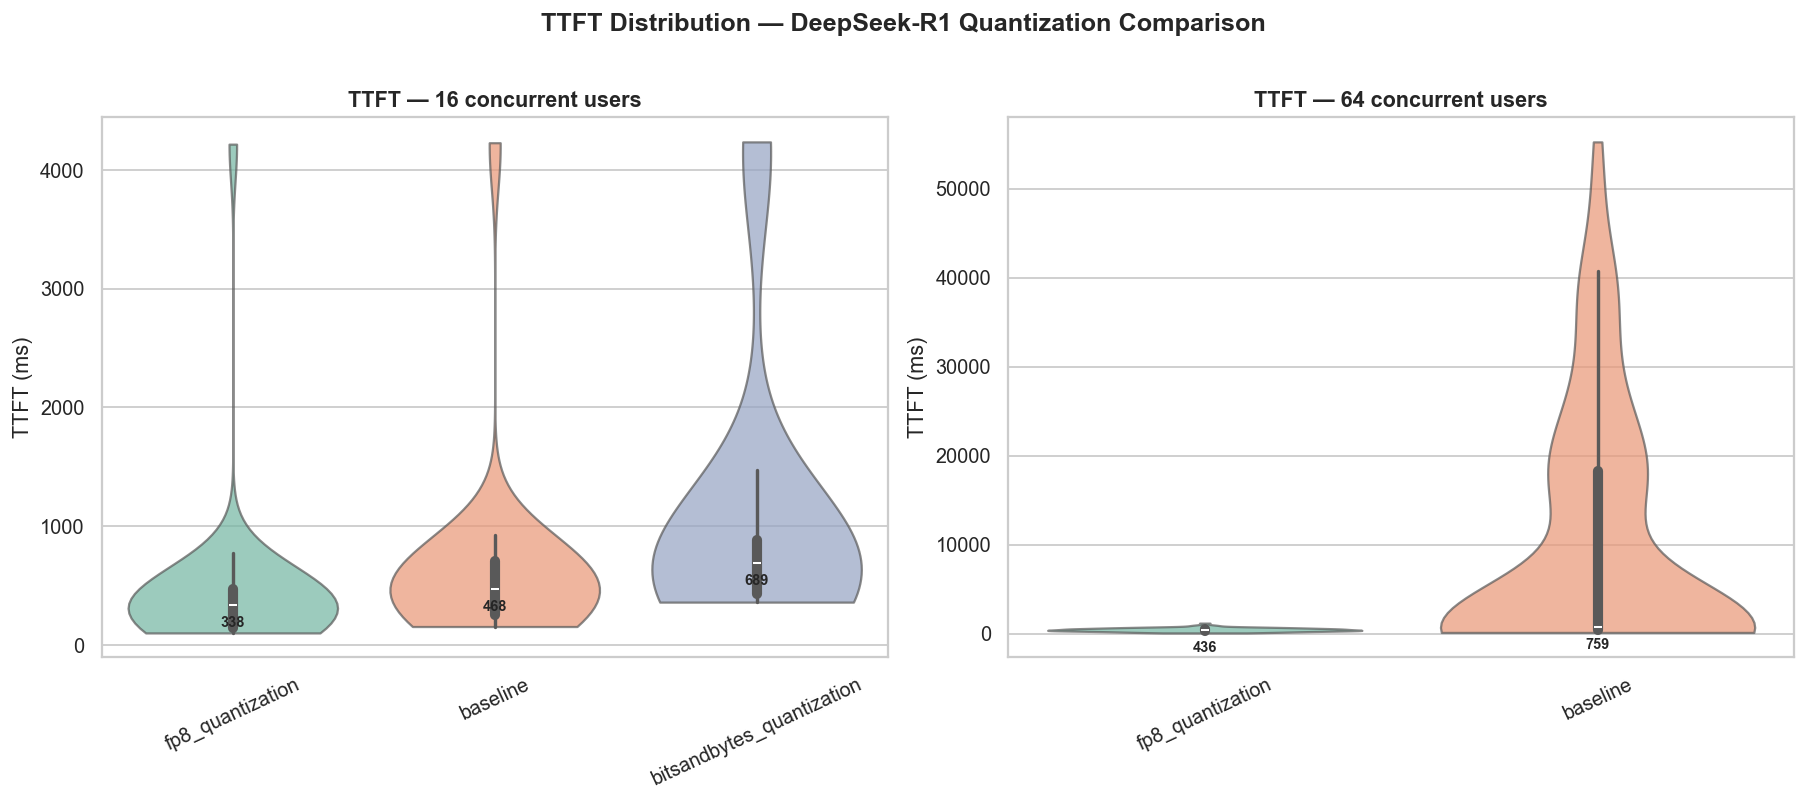

In [6]:
# ─── TTFT Distribution: Quantization × Reasoning Model ───────────────────────
ok_qr = df_quant_r[df_quant_r['success'] == True].copy()
user_levels = sorted(ok_qr['users'].unique())

fig, axes = plt.subplots(1, len(user_levels), figsize=(7 * len(user_levels), 6), sharey=False)
if len(user_levels) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = ok_qr[ok_qr['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TTFT — {u} concurrent users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TTFT (ms)')
    ax.tick_params(axis='x', rotation=25)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('TTFT Distribution — DeepSeek-R1 Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

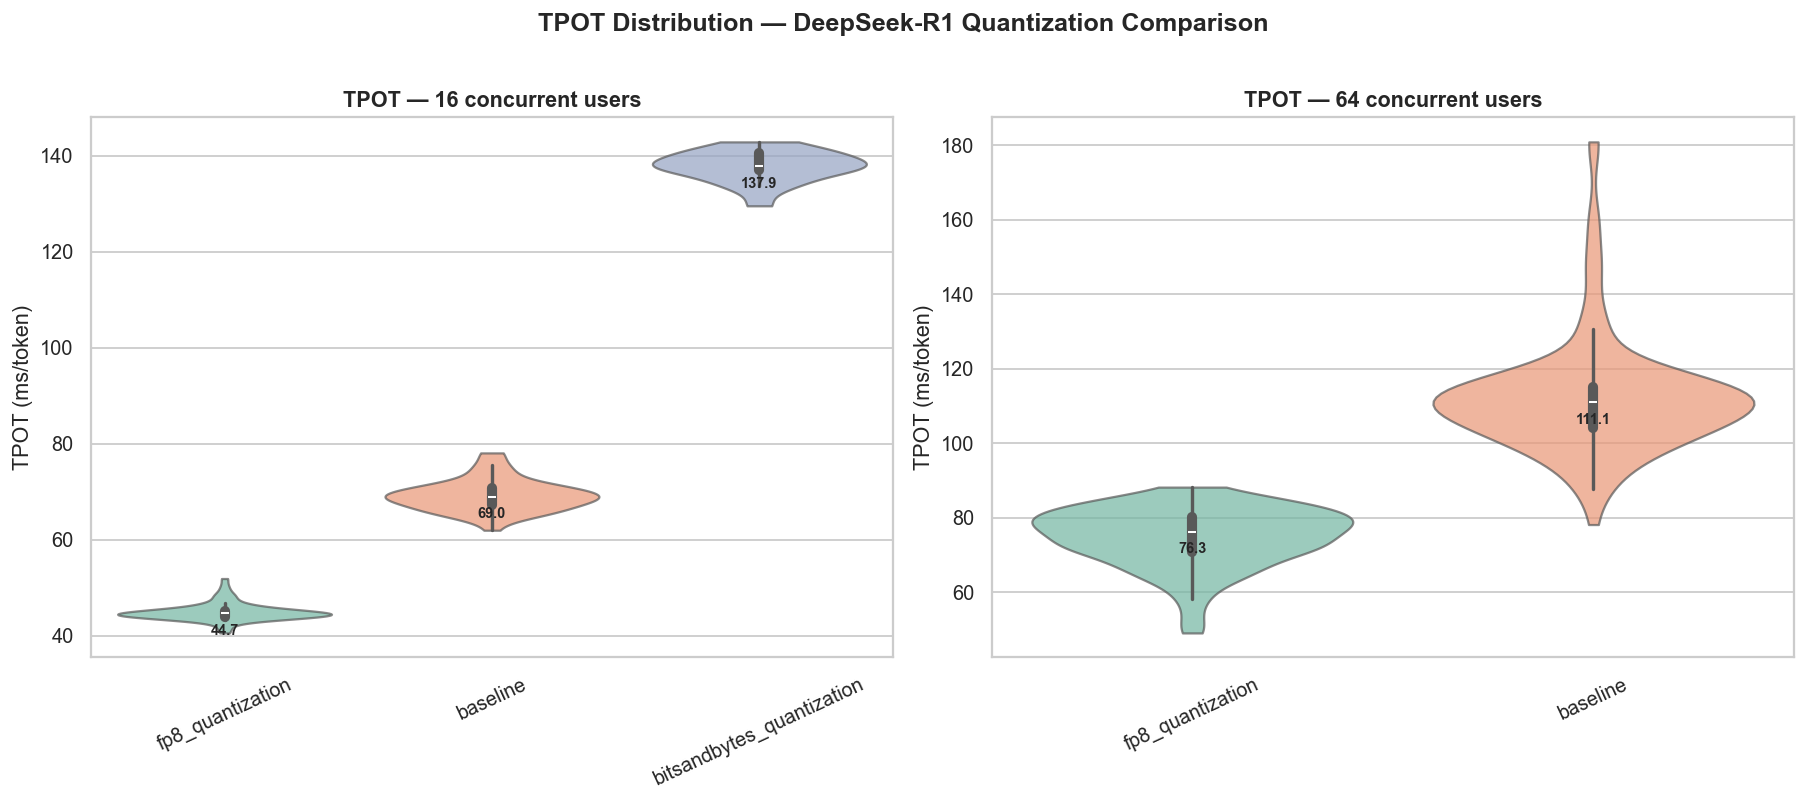

In [7]:
# ─── TPOT Distribution: Quantization × Reasoning Model ───────────────────────
fig, axes = plt.subplots(1, len(user_levels), figsize=(7 * len(user_levels), 6), sharey=False)
if len(user_levels) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = ok_qr[ok_qr['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TPOT — {u} concurrent users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TPOT (ms/token)')
    ax.tick_params(axis='x', rotation=25)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['tpot_ms'].median()
        ax.annotate(f'{med:.1f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('TPOT Distribution — DeepSeek-R1 Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

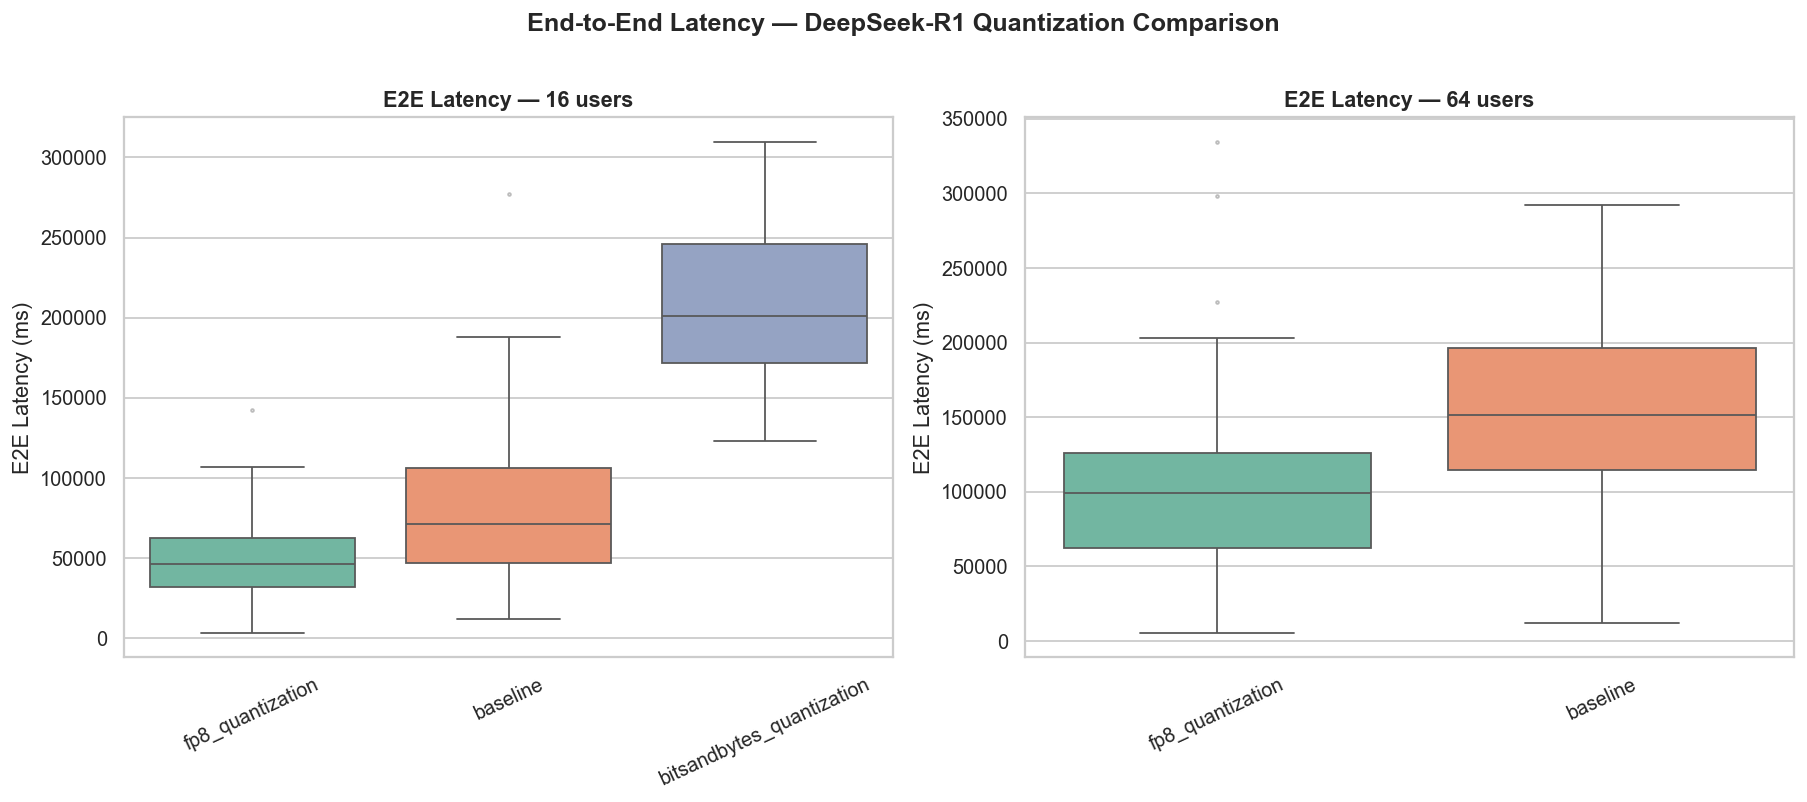

In [8]:
# ─── E2E Latency Boxplot: Quantization × Reasoning Model ─────────────────────
fig, axes = plt.subplots(1, len(user_levels), figsize=(7 * len(user_levels), 6), sharey=False)
if len(user_levels) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = ok_qr[ok_qr['users'] == u]
    order = sub.groupby('experiment')['e2e_ms'].median().sort_values().index
    sns.boxplot(data=sub, x='experiment', y='e2e_ms', order=order,
                ax=ax, palette='Set2', flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_title(f'E2E Latency — {u} users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('E2E Latency (ms)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('End-to-End Latency — DeepSeek-R1 Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

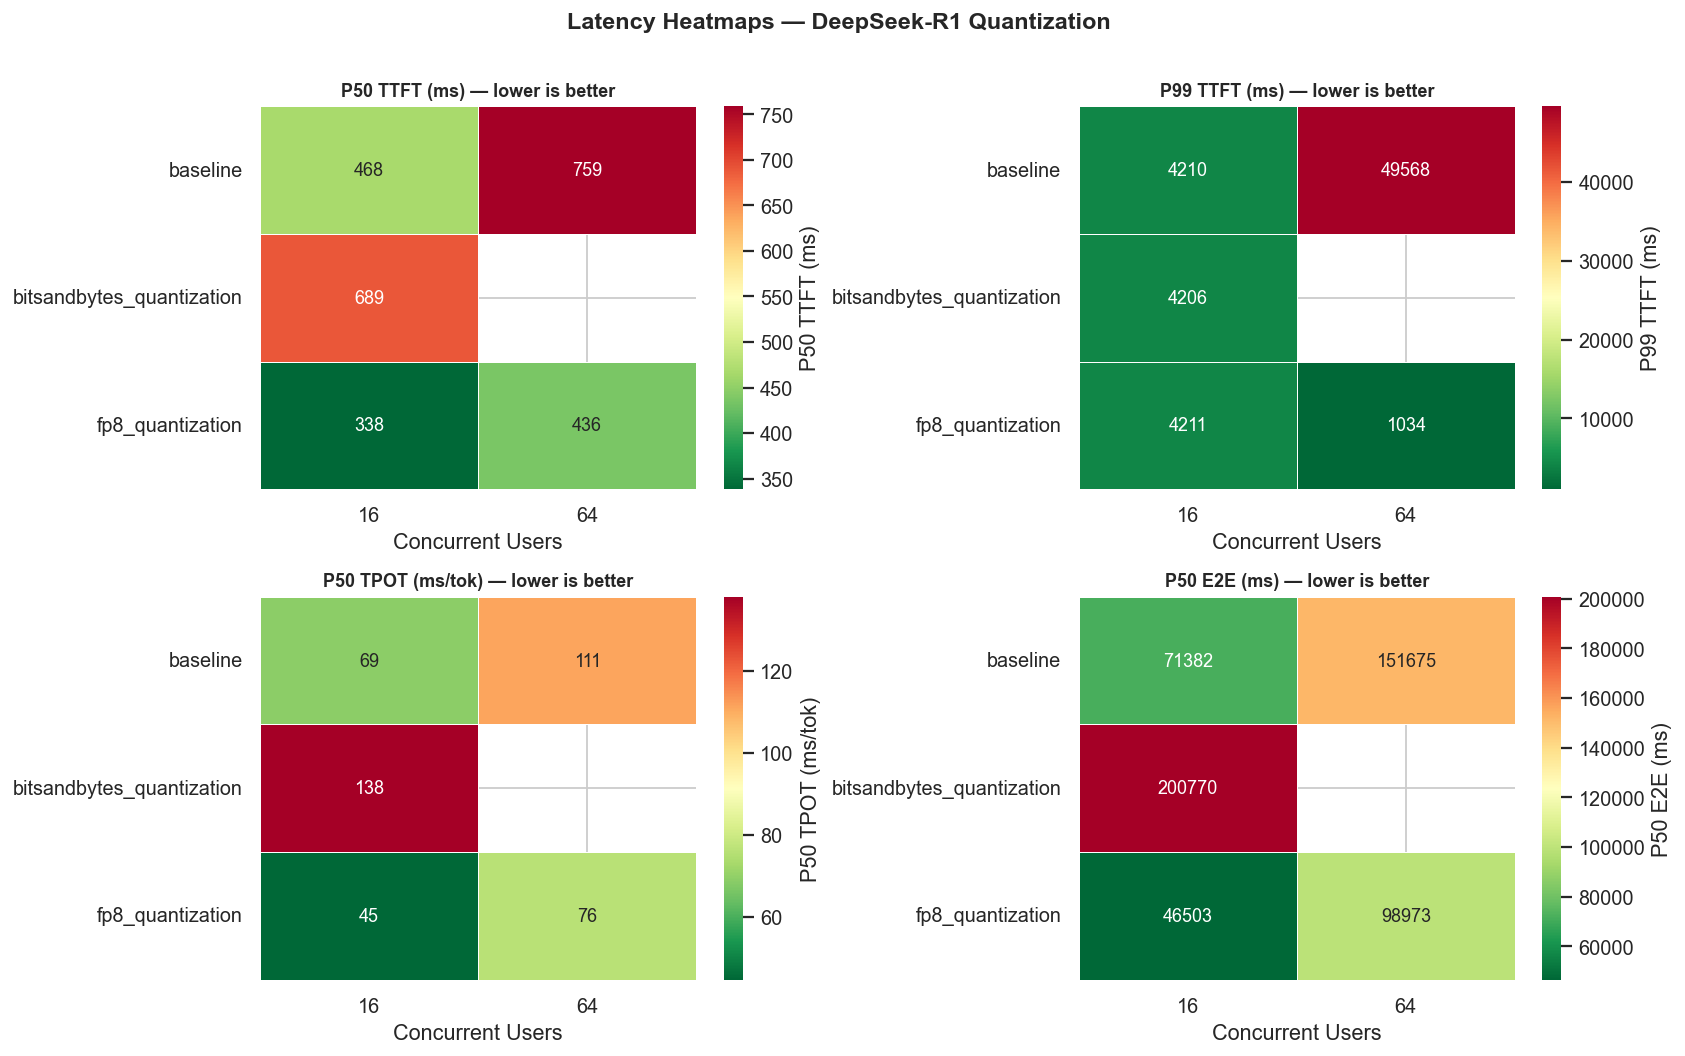

In [9]:
# ─── Latency Heatmaps: Reasoning Quantization ────────────────────────────────
metrics_hm = [
    ('ttft_p50', 'P50 TTFT (ms)'),
    ('ttft_p99', 'P99 TTFT (ms)'),
    ('tpot_p50', 'P50 TPOT (ms/tok)'),
    ('e2e_p50',  'P50 E2E (ms)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, title) in zip(axes.flat, metrics_hm):
    pivot = sum_qr.pivot_table(index='experiment', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=10)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')

plt.suptitle('Latency Heatmaps — DeepSeek-R1 Quantization', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# Part 2 — Quantization Impact: Non-Reasoning Model (Qwen2.5)

Comparing **baseline (FP16)** vs **FP8** on Qwen2.5-7B-Instruct.  
Note: BitsAndBytes data was not collected (server failed to start), and FP8 u64 has no custom_metrics.

In [10]:
# ─── Summary table: Quantization on Non-Reasoning Model ──────────────────────
print('Quantization Comparison — Qwen2.5 (Non-Reasoning):')
display(sum_qnr)

Quantization Comparison — Qwen2.5 (Non-Reasoning):


,experiment,users,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,non_reasoning_baseline,16,83,796.6,574.5,1089.4,8481.8,74.8,71.8,133.5,44189.9,41955.2,115770.4,64.6,342.9,49461
1,non_reasoning_baseline,64,206,742.0,672.0,1514.8,2001.0,125.8,127.3,177.3,76764.6,77512.4,237607.3,92.9,667.5,129452
2,non_reasoning_fp8,16,95,440.8,403.1,739.8,857.0,69.5,69.6,77.6,39714.1,39369.0,98577.2,63.2,288.4,54172


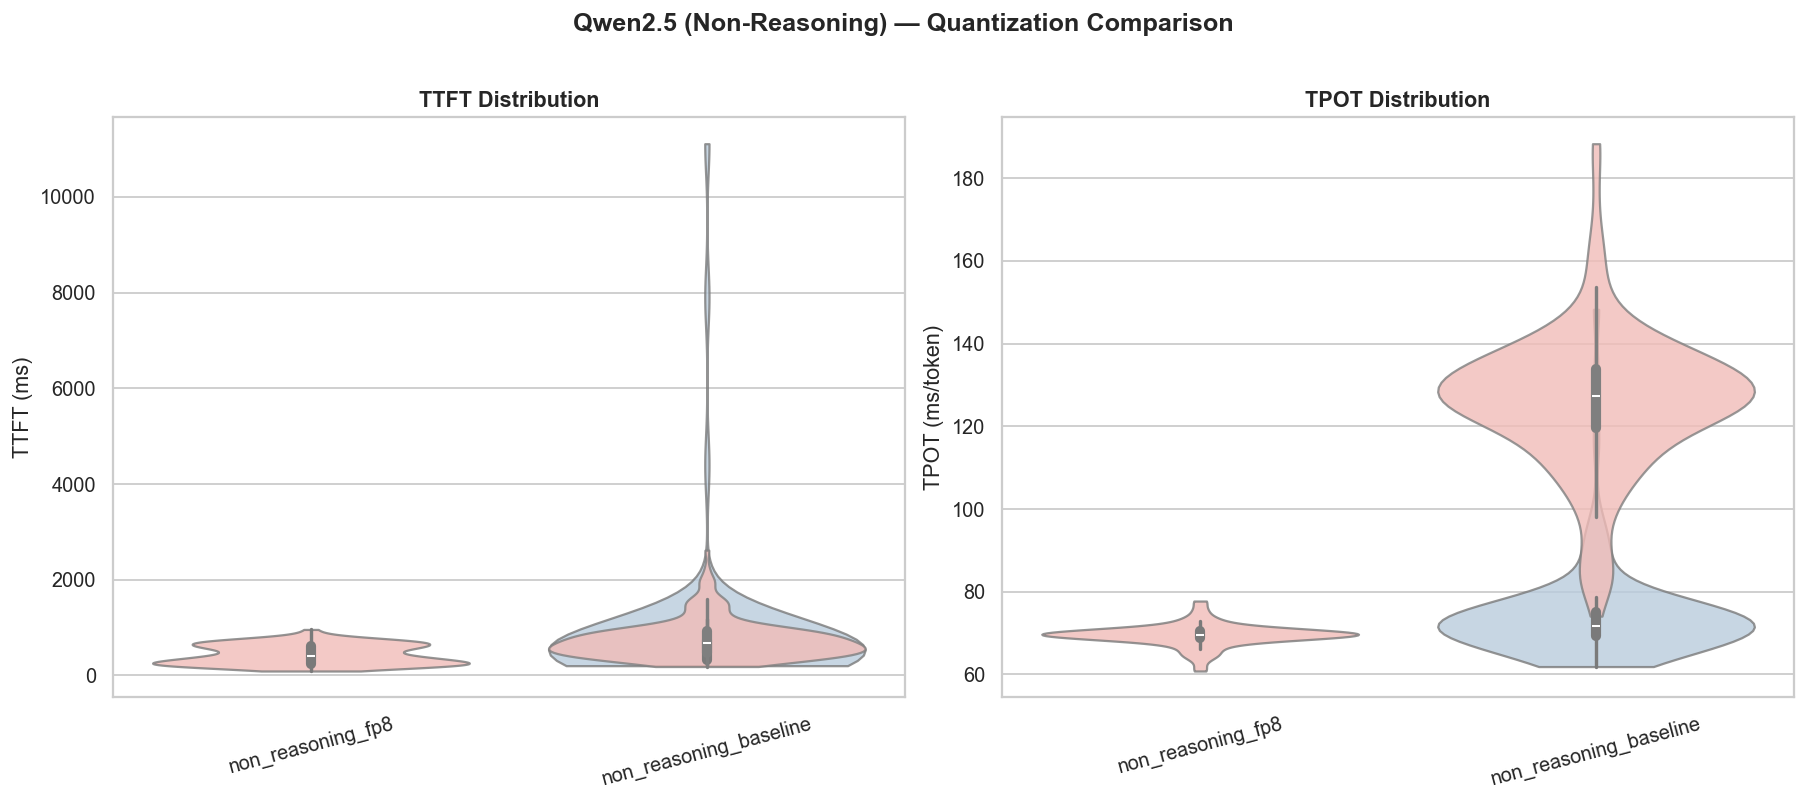

In [11]:
# ─── TTFT + TPOT: Non-Reasoning Model ────────────────────────────────────────
ok_qnr = df_quant_nr[df_quant_nr['success'] == True].copy()
user_levels_nr = sorted(ok_qnr['users'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# TTFT
for u in user_levels_nr:
    sub = ok_qnr[ok_qnr['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order,
                   inner='box', cut=0, ax=axes[0], palette='Pastel1', alpha=0.8)
axes[0].set_title('TTFT Distribution', fontweight='bold')
axes[0].set_ylabel('TTFT (ms)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# TPOT
for u in user_levels_nr:
    sub = ok_qnr[ok_qnr['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order,
                   inner='box', cut=0, ax=axes[1], palette='Pastel1', alpha=0.8)
axes[1].set_title('TPOT Distribution', fontweight='bold')
axes[1].set_ylabel('TPOT (ms/token)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Qwen2.5 (Non-Reasoning) — Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3 — Reasoning vs Non-Reasoning Model Comparison

Comparing DeepSeek-R1 (reasoning) baselines vs Qwen2.5 (non-reasoning) baselines to see the inherent latency difference between reasoning and non-reasoning models.

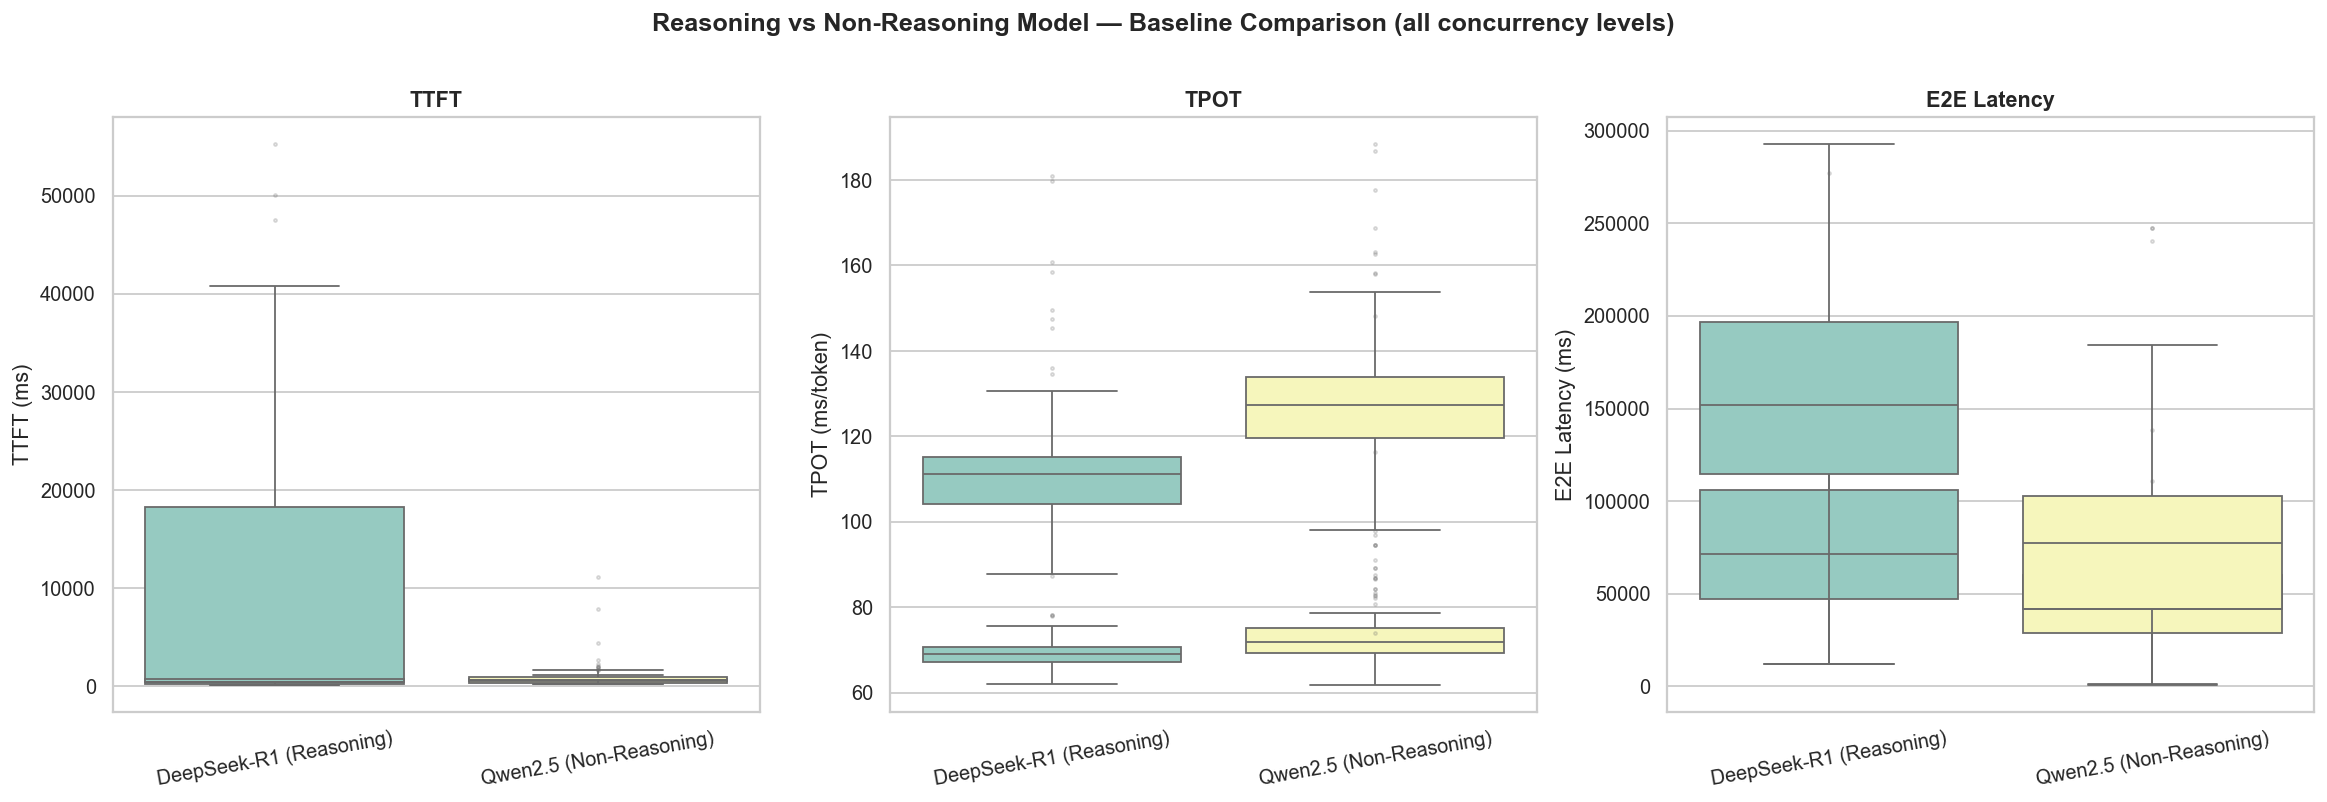

Reasoning vs Non-Reasoning — Baseline Summary:


,model,users,n,ttft_median,tpot_median,e2e_median,output_tokens_total
0,DeepSeek-R1 (Reasoning),16,47,468.0,69.0,71381.8,58852
1,DeepSeek-R1 (Reasoning),64,121,758.6,111.1,151674.7,155832
2,Qwen2.5 (Non-Reasoning),16,83,574.5,71.8,41955.2,49461
3,Qwen2.5 (Non-Reasoning),64,206,672.0,127.3,77512.4,129452


In [12]:
# ─── Cross-Model Comparison: Reasoning vs Non-Reasoning ──────────────────────
# Pick baseline experiments from both models at u16
ok_r_base  = df_quant_r[(df_quant_r['success'] == True) & (df_quant_r['experiment'] == 'baseline')].copy()
ok_nr_base = df_quant_nr[(df_quant_nr['success'] == True) & (df_quant_nr['experiment'] == 'non_reasoning_baseline')].copy()

ok_r_base['model']  = 'DeepSeek-R1 (Reasoning)'
ok_nr_base['model'] = 'Qwen2.5 (Non-Reasoning)'

cross = pd.concat([ok_r_base, ok_nr_base], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [('ttft_ms', 'TTFT (ms)'), ('tpot_ms', 'TPOT (ms/token)'), ('e2e_ms', 'E2E Latency (ms)')]

for ax, (col, ylabel) in zip(axes, metrics):
    for u in sorted(cross['users'].unique()):
        sub = cross[cross['users'] == u]
        sns.boxplot(data=sub, x='model', y=col, ax=ax, palette='Set3',
                    flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_title(ylabel.split('(')[0].strip(), fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Reasoning vs Non-Reasoning Model — Baseline Comparison (all concurrency levels)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
comparison_summary = cross.groupby(['model', 'users']).agg(
    n=('ttft_ms', 'count'),
    ttft_median=('ttft_ms', 'median'),
    tpot_median=('tpot_ms', 'median'),
    e2e_median=('e2e_ms', 'median'),
    output_tokens_total=('output_tokens', 'sum'),
).reset_index()
print('Reasoning vs Non-Reasoning — Baseline Summary:')
display(comparison_summary)

---
# Part 4 — I/O Profile Analysis

How different prompt types (coding, creative, reasoning, long-input, short-input) affect latency and throughput.  
All profiles tested on DeepSeek-R1 (FP16 baseline) at u16 and u64.

In [13]:
# ─── Summary: I/O Profiles ────────────────────────────────────────────────────
print('I/O Profile Summary:')
display(sum_io)

I/O Profile Summary:


,experiment,users,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,custom_all_profiles,16,44,184.8,193.0,202.1,229.7,61.8,62.1,63.0,93150.5,92863.9,127728.2,61.6,70.2,66186
1,custom_all_profiles,64,153,249.7,268.5,310.0,334.0,81.8,82.7,88.2,115700.0,117771.6,174844.1,81.2,124.4,216024
2,custom_coding_only,16,45,187.6,194.0,207.6,216.0,61.6,61.7,62.5,94496.1,124261.0,127455.4,61.4,69.8,69012
3,custom_coding_only,64,150,245.8,262.4,316.5,323.6,81.8,83.0,88.2,123617.1,149412.2,176512.5,81.3,122.3,225438
4,custom_creative_only,16,42,184.6,192.9,201.3,211.9,61.8,62.1,62.4,100620.7,101755.5,127597.2,61.6,67.7,68309
5,custom_creative_only,64,135,245.7,260.8,314.3,333.4,82.3,82.8,88.0,140257.0,151590.7,175682.6,82.2,122.9,229745
6,custom_long_input_only,16,34,194.5,192.2,240.2,260.5,62.2,62.4,63.2,119235.6,126042.7,128501.6,62.0,70.7,65068
7,custom_long_input_only,64,128,254.0,259.3,363.6,376.9,84.7,85.5,88.4,161275.4,169961.2,180306.8,84.7,131.6,243538
8,custom_reasoning_only,16,44,189.0,195.3,204.0,237.8,62.0,62.1,63.1,91903.8,124599.5,128184.5,61.6,73.4,65163
9,custom_reasoning_only,64,149,247.9,247.9,327.4,348.5,82.1,83.1,92.0,131126.3,164182.8,179211.1,81.5,129.7,234766


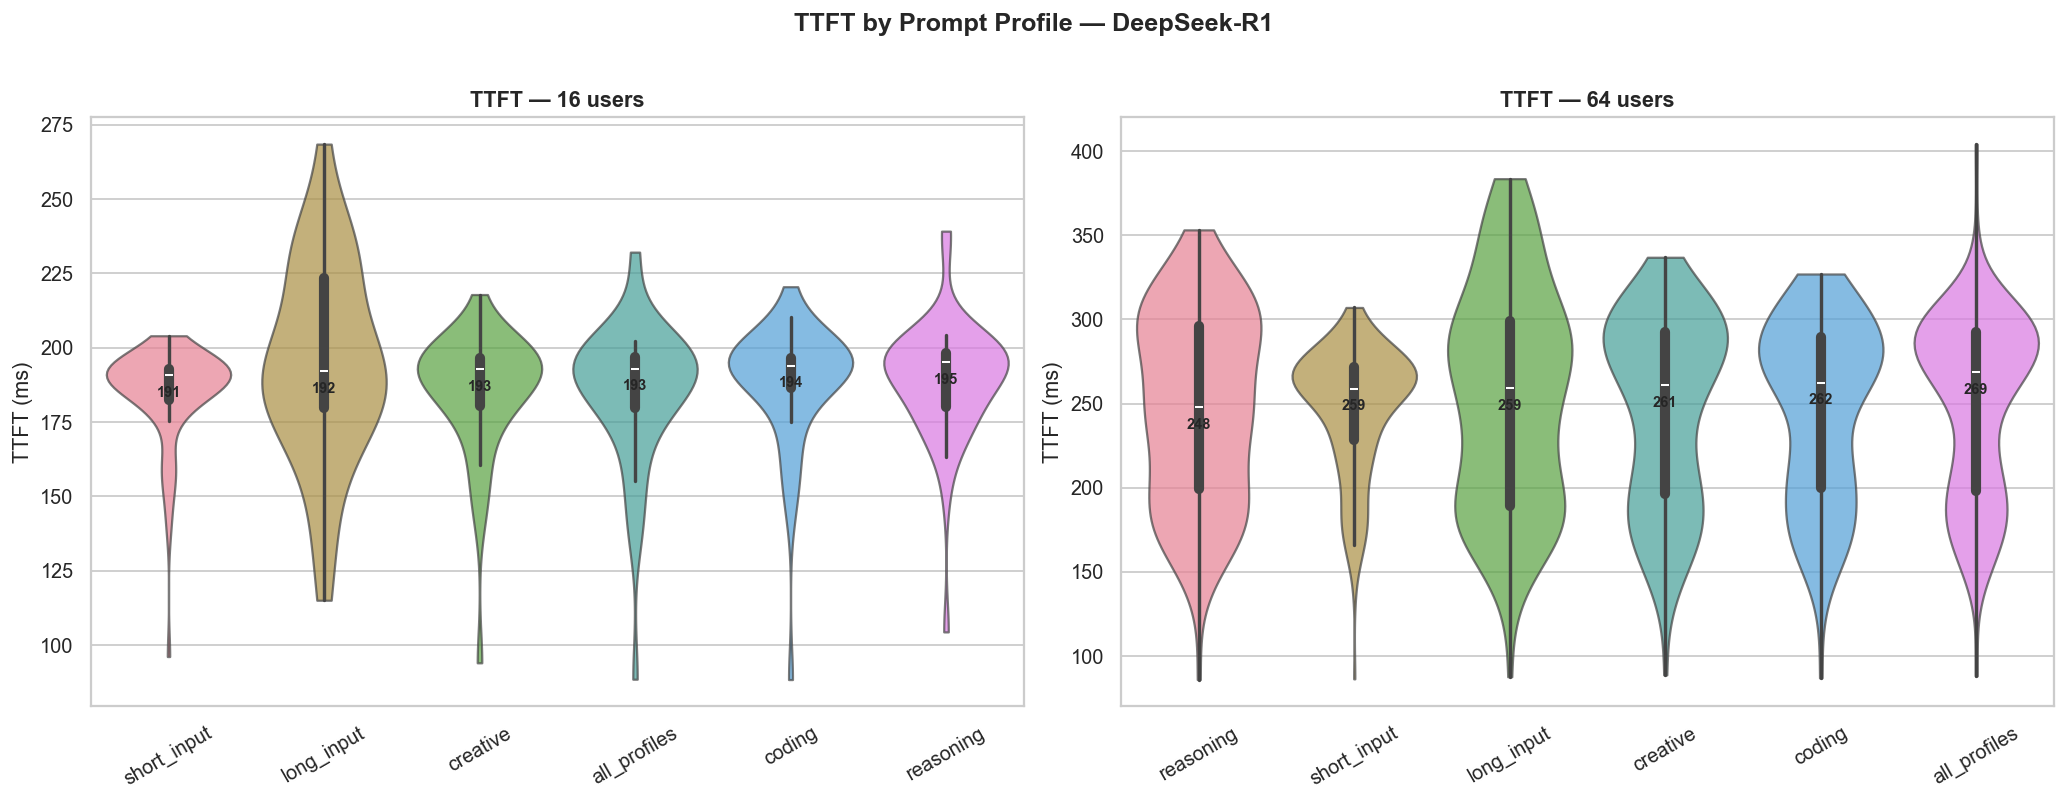

In [14]:
# ─── TTFT by I/O Profile ──────────────────────────────────────────────────────
ok_io = df_io[df_io['success'] == True].copy()

# Clean experiment names for readability
ok_io['profile'] = ok_io['experiment'].str.replace('custom_', '').str.replace('_only', '')
sum_io_clean = sum_io.copy()
sum_io_clean['profile'] = sum_io_clean['experiment'].str.replace('custom_', '').str.replace('_only', '')

user_levels_io = sorted(ok_io['users'].unique())

fig, axes = plt.subplots(1, len(user_levels_io), figsize=(8 * len(user_levels_io), 6), sharey=False)
if len(user_levels_io) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_io):
    sub = ok_io[ok_io['users'] == u]
    order = sub.groupby('profile')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='profile', y='ttft_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='husl', alpha=0.7)
    ax.set_title(f'TTFT — {u} users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TTFT (ms)')
    ax.tick_params(axis='x', rotation=30)
    for i, exp in enumerate(order):
        med = sub[sub['profile'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('TTFT by Prompt Profile — DeepSeek-R1', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

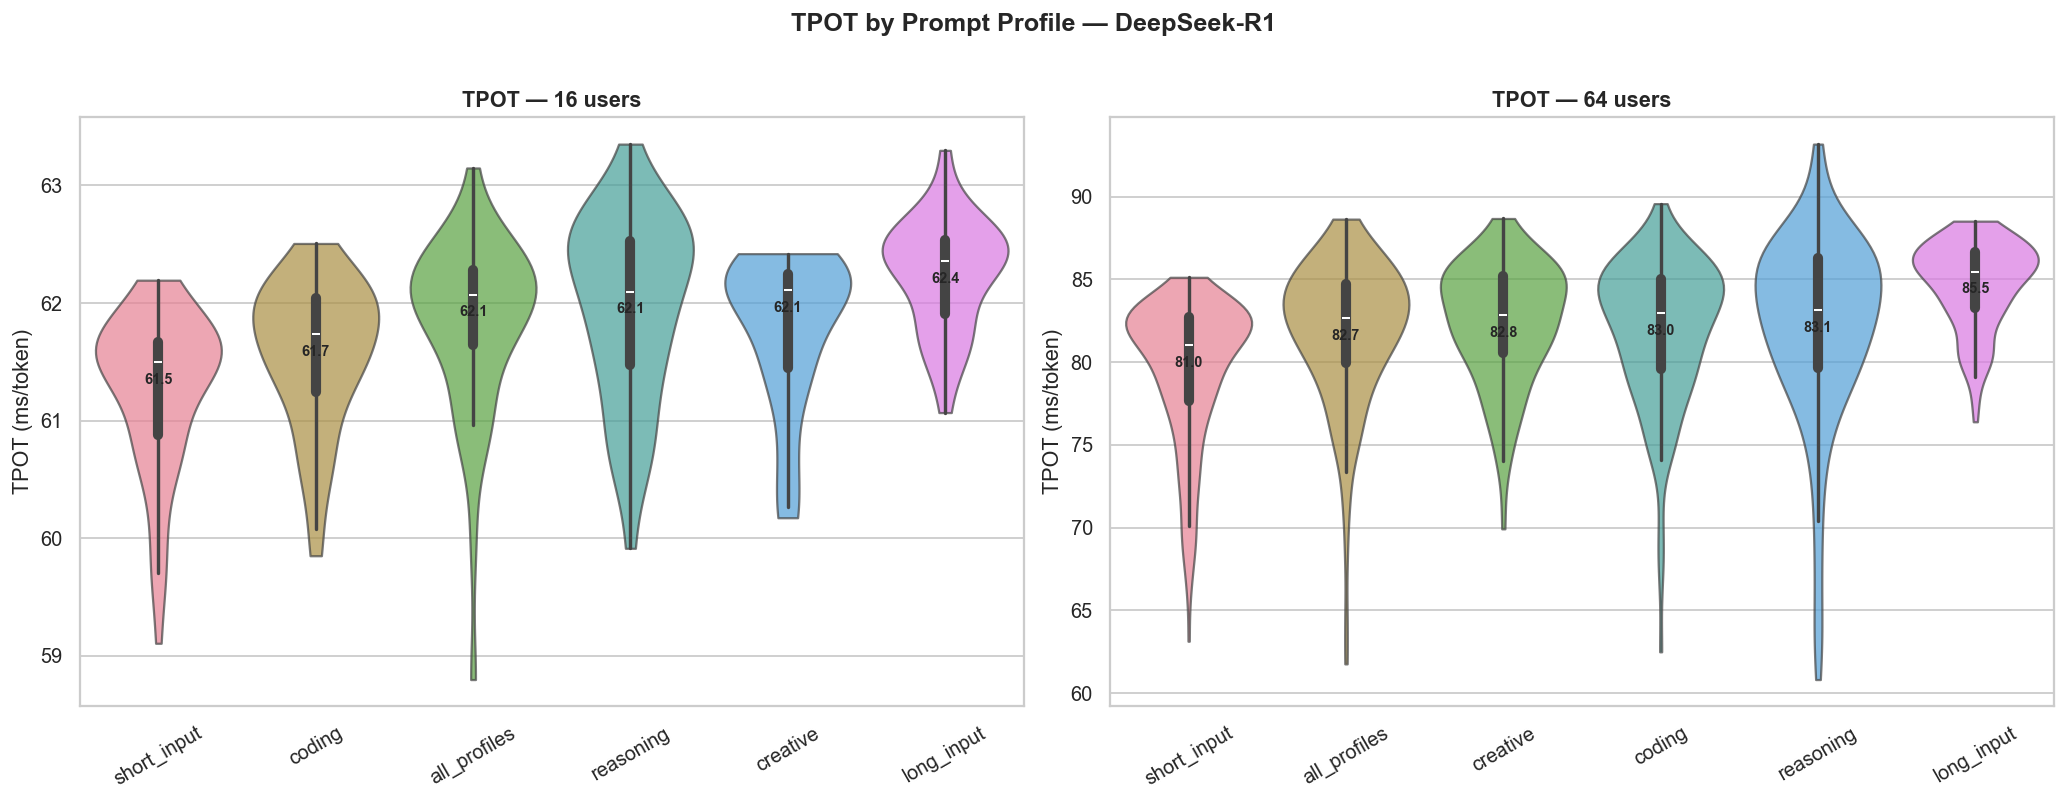

In [15]:
# ─── TPOT by I/O Profile ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(user_levels_io), figsize=(8 * len(user_levels_io), 6), sharey=False)
if len(user_levels_io) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_io):
    sub = ok_io[ok_io['users'] == u]
    order = sub.groupby('profile')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='profile', y='tpot_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='husl', alpha=0.7)
    ax.set_title(f'TPOT — {u} users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TPOT (ms/token)')
    ax.tick_params(axis='x', rotation=30)
    for i, exp in enumerate(order):
        med = sub[sub['profile'] == exp]['tpot_ms'].median()
        ax.annotate(f'{med:.1f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('TPOT by Prompt Profile — DeepSeek-R1', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

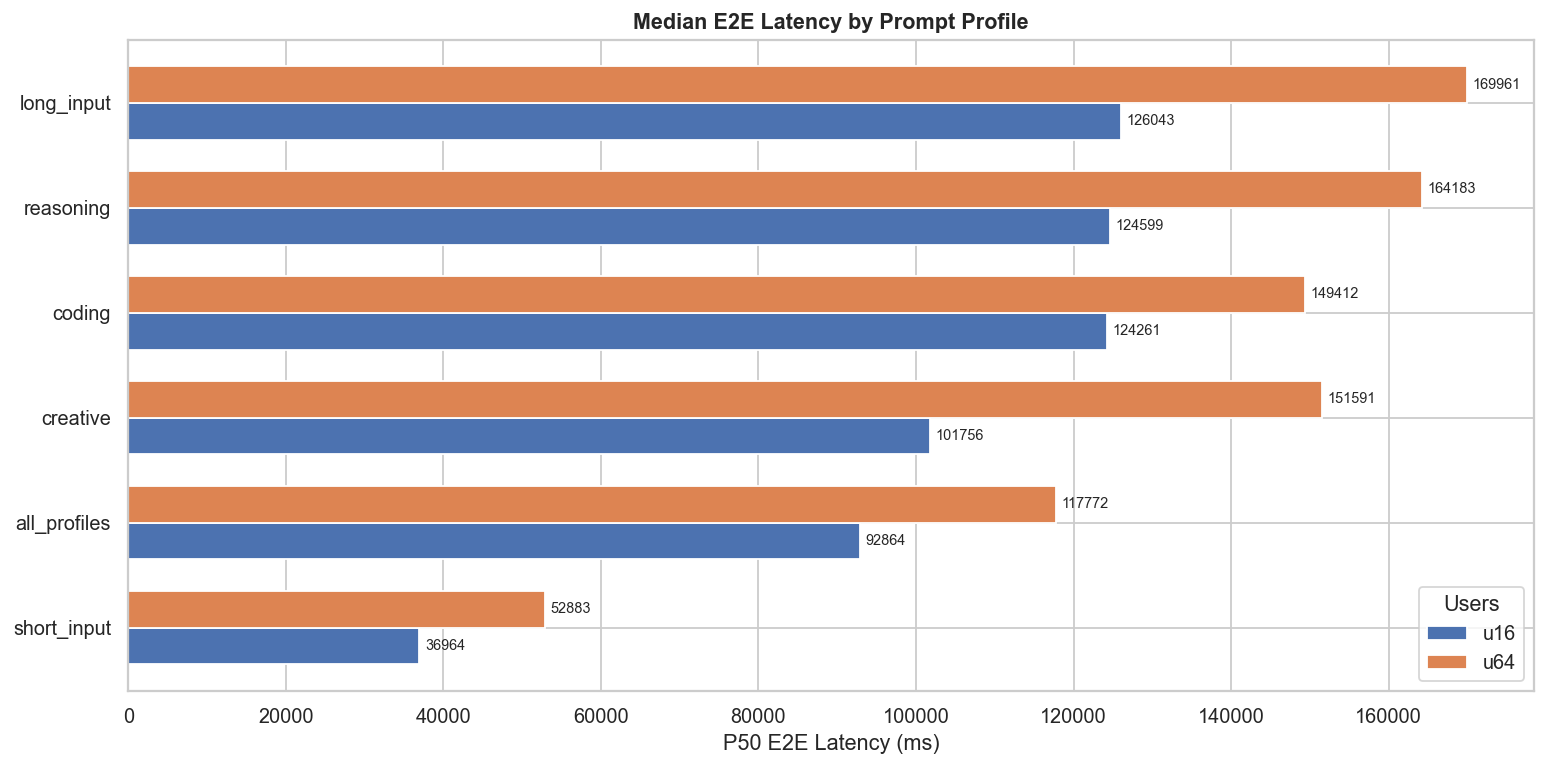

In [16]:
# ─── E2E Latency by Profile (Grouped Bar) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

e2e_pivot = sum_io_clean.pivot_table(index='profile', columns='users', values='e2e_p50', aggfunc='mean')
e2e_pivot = e2e_pivot.reindex(e2e_pivot.mean(axis=1).sort_values().index)
e2e_pivot.plot(kind='barh', ax=ax, width=0.7, color=['#4C72B0', '#DD8452'])

ax.set_xlabel('P50 E2E Latency (ms)')
ax.set_title('Median E2E Latency by Prompt Profile', fontweight='bold')
ax.set_ylabel('')
ax.legend(title='Users', labels=[f'u{c}' for c in e2e_pivot.columns])
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=8)
ax.bar_label(ax.containers[1], fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

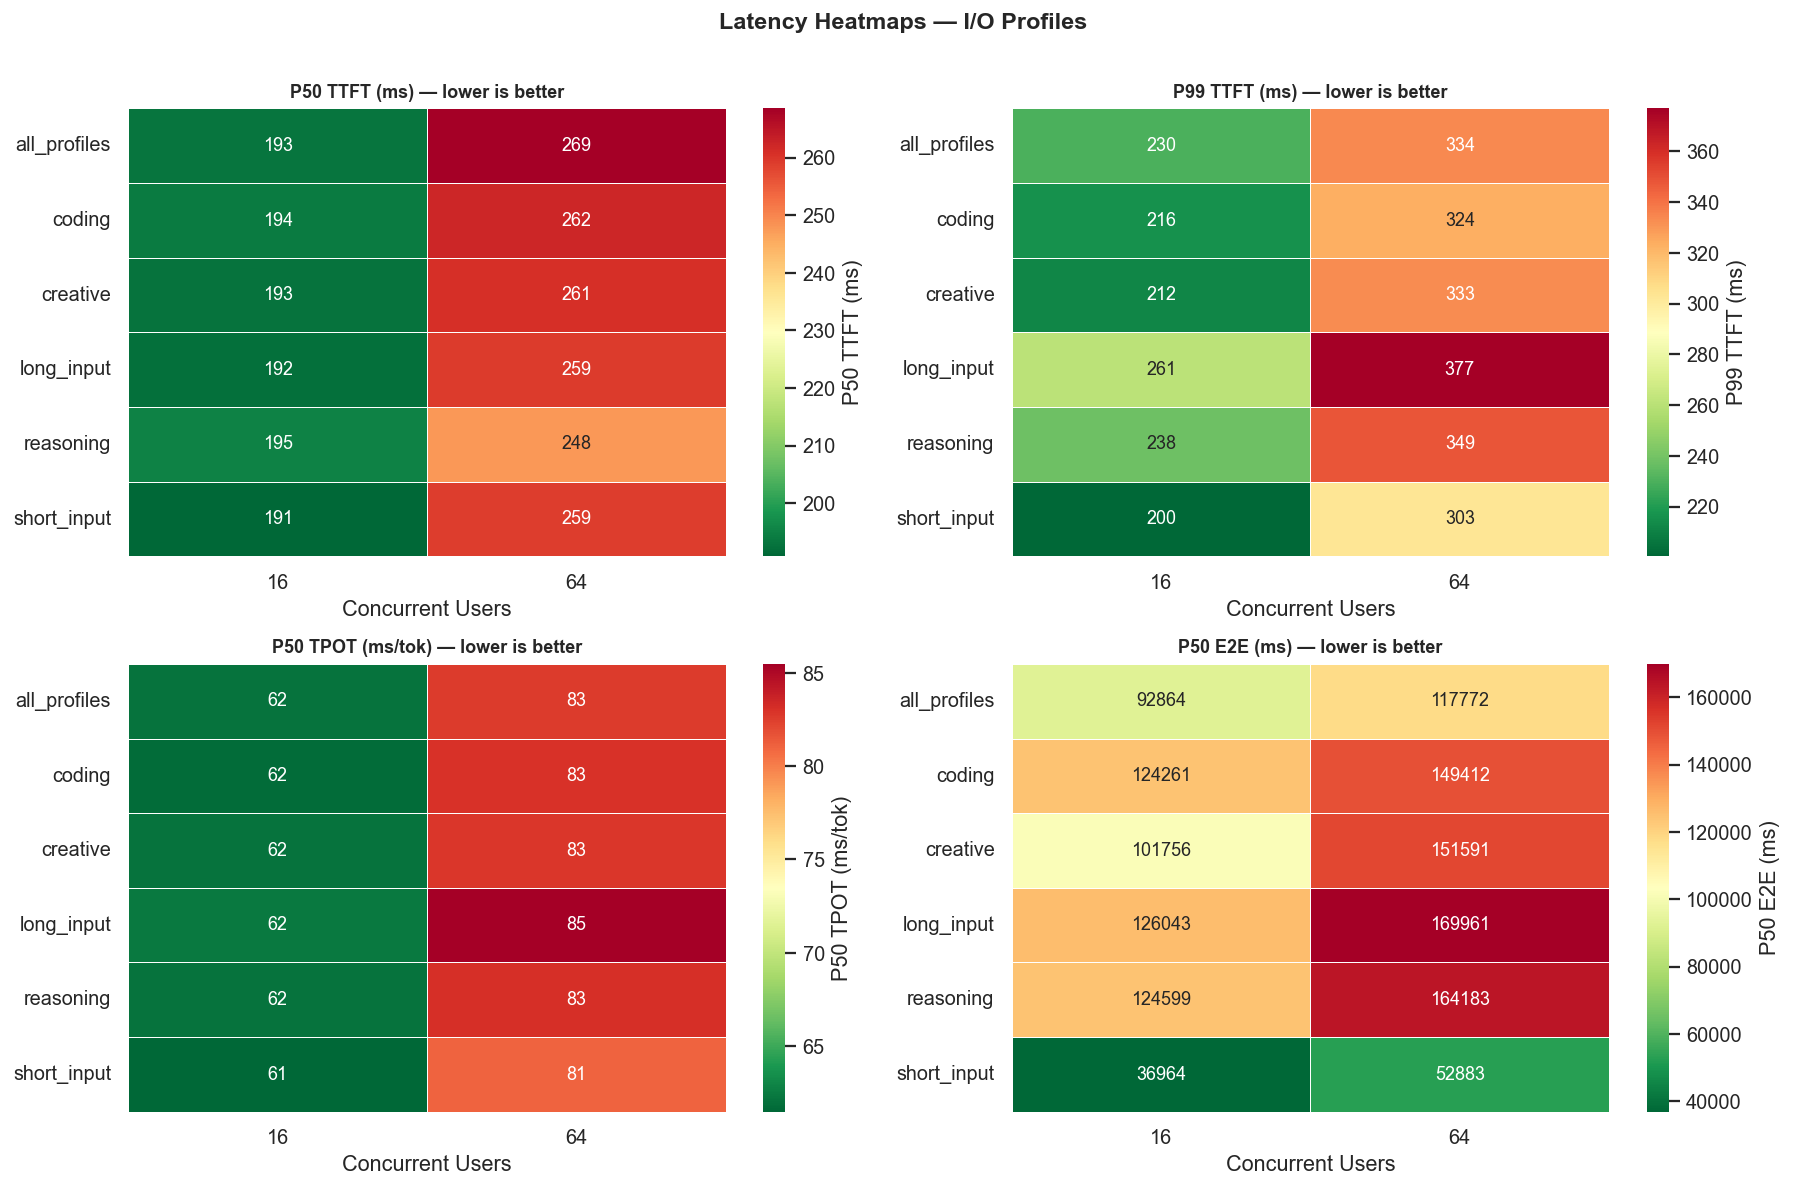

In [17]:
# ─── I/O Profile: Heatmap of key latency metrics ─────────────────────────────
metrics_io_hm = [
    ('ttft_p50', 'P50 TTFT (ms)'),
    ('ttft_p99', 'P99 TTFT (ms)'),
    ('tpot_p50', 'P50 TPOT (ms/tok)'),
    ('e2e_p50',  'P50 E2E (ms)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, title) in zip(axes.flat, metrics_io_hm):
    pivot = sum_io_clean.pivot_table(index='profile', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=10)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')

plt.suptitle('Latency Heatmaps — I/O Profiles', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

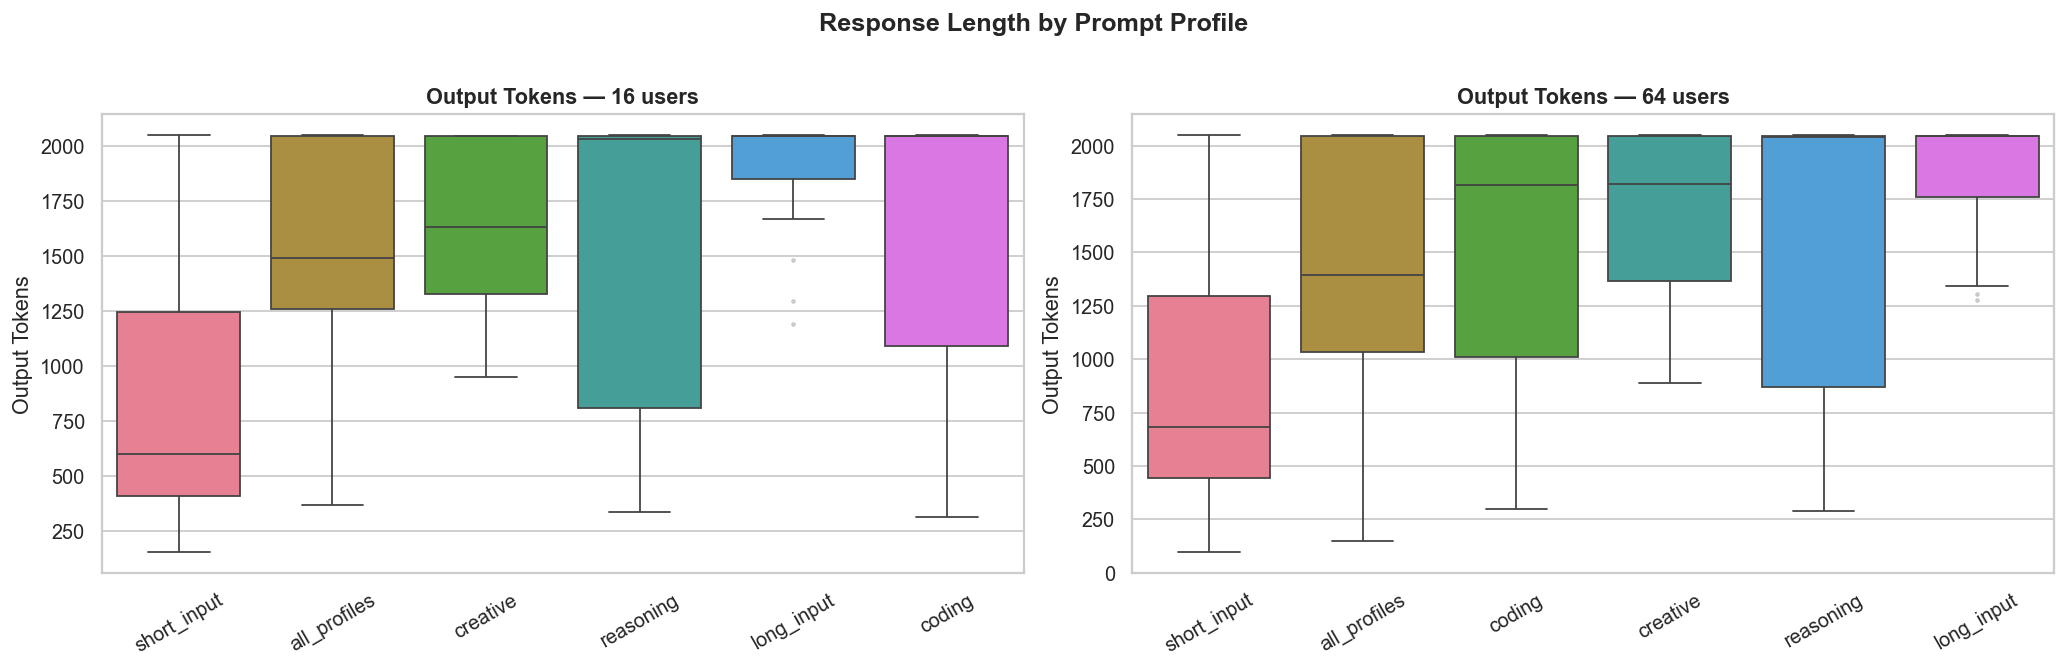

In [18]:
# ─── I/O Profile: Output Tokens Distribution (response length) ────────────────
fig, axes = plt.subplots(1, len(user_levels_io), figsize=(8 * len(user_levels_io), 5), sharey=False)
if len(user_levels_io) == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_io):
    sub = ok_io[ok_io['users'] == u]
    order = sub.groupby('profile')['output_tokens'].median().sort_values().index
    sns.boxplot(data=sub, x='profile', y='output_tokens', order=order,
                ax=ax, palette='husl', flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_title(f'Output Tokens — {u} users', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Output Tokens')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Response Length by Prompt Profile', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Part 5 — Prometheus Server-Side Metrics

GPU utilization, KV cache usage, queue depth, and generation throughput from the vLLM Prometheus endpoint.

In [19]:
# ─── Helper: pivot prometheus long-form → wide-form per timestamp ─────────────
def prom_wide(prom_df: pd.DataFrame) -> pd.DataFrame:
    if prom_df.empty:
        return pd.DataFrame()
    wide = prom_df.pivot_table(
        index=['experiment', 'users', 'run', 'timestamp'],
        columns='metric_name',
        values='value',
        aggfunc='first'
    ).reset_index()
    wide.columns.name = None
    return wide

pw_qr  = prom_wide(prom_quant_r)
pw_qnr = prom_wide(prom_quant_nr)
pw_io  = prom_wide(prom_io)

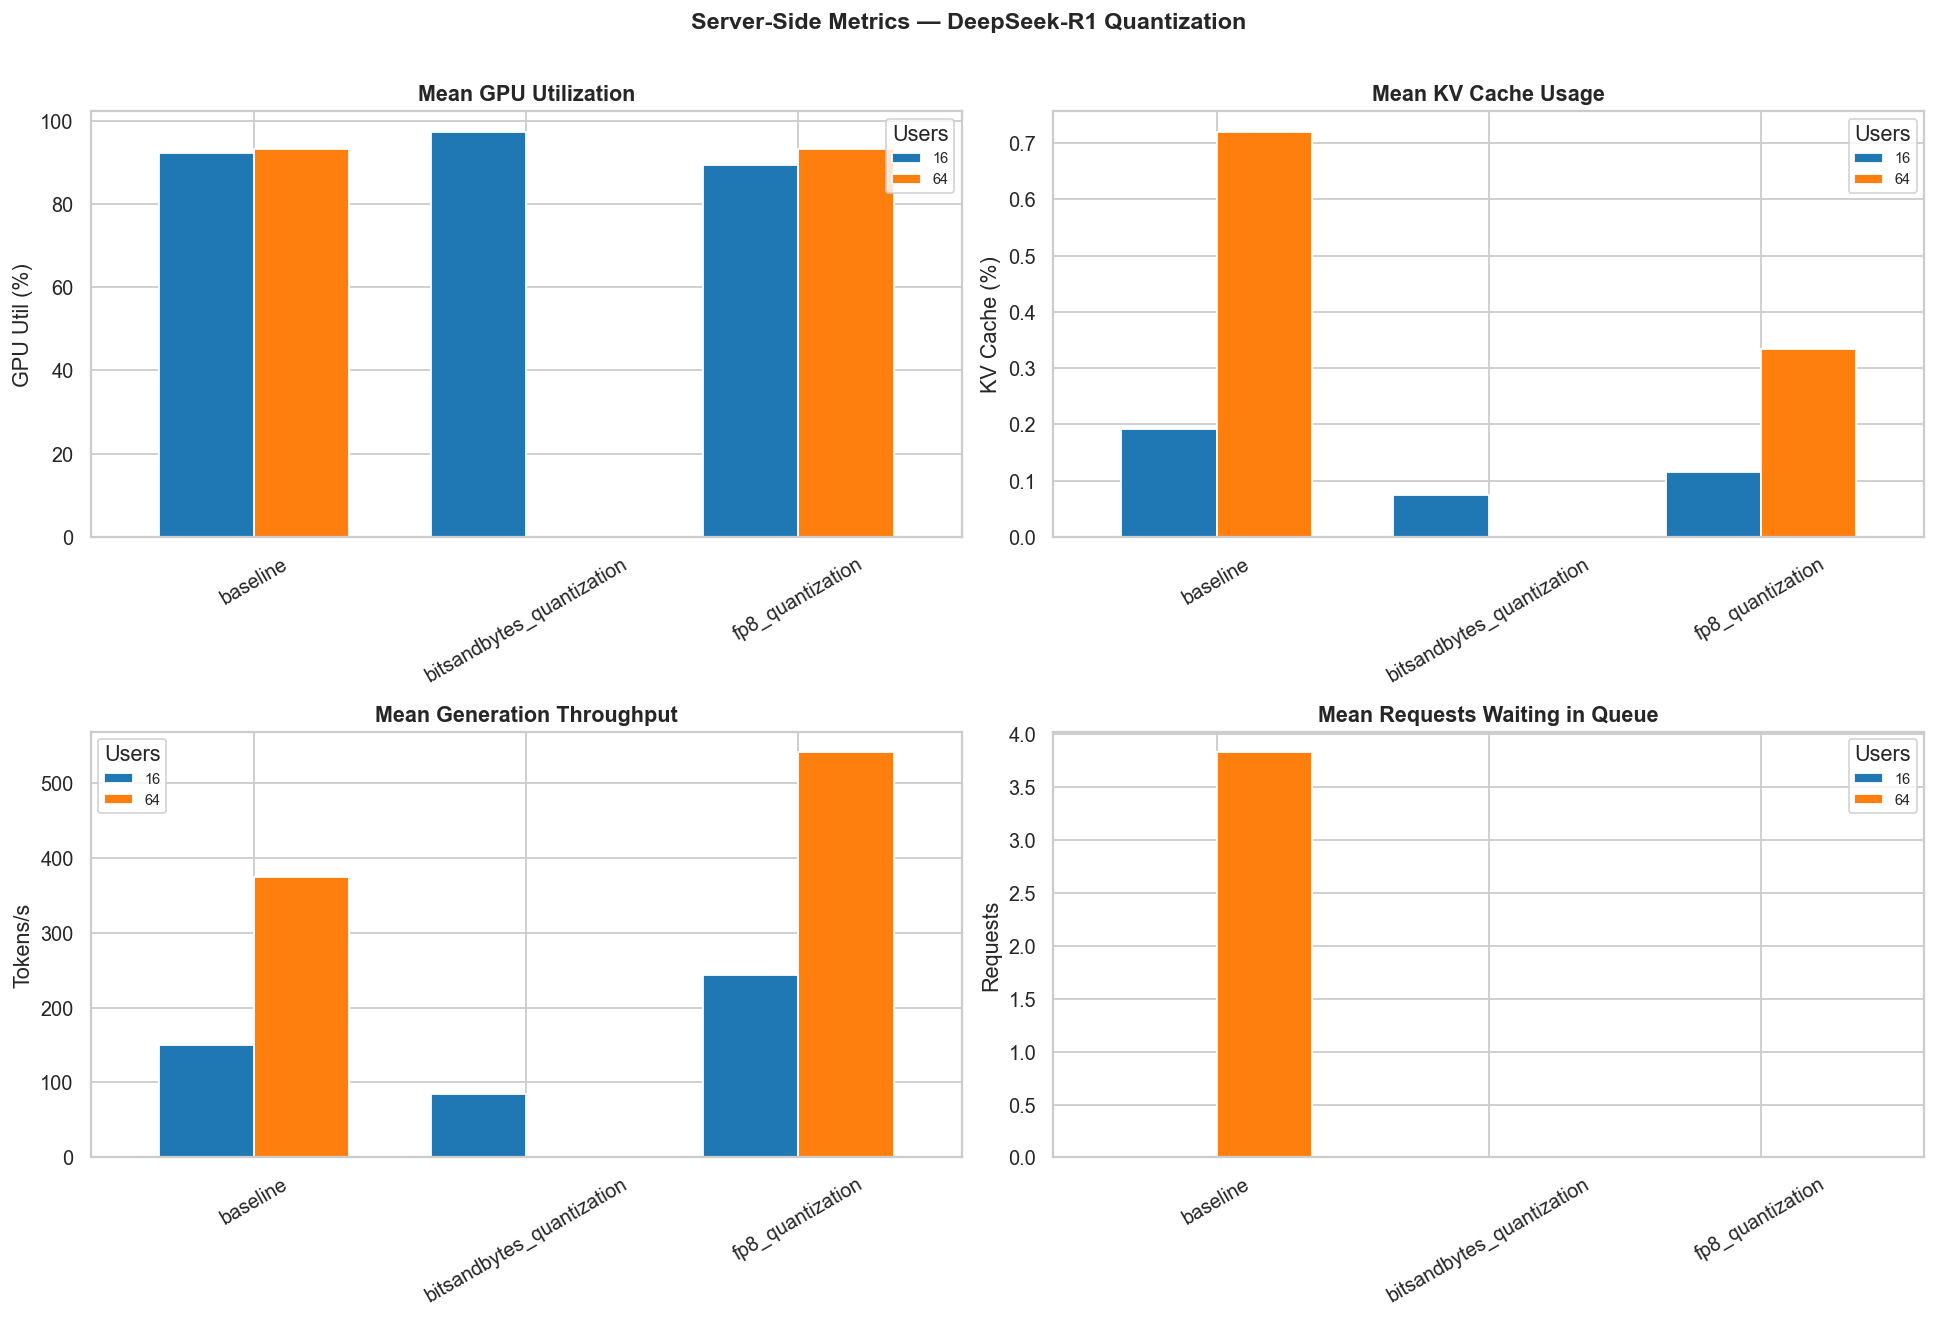

In [20]:
# ─── GPU Utilization & KV Cache: Reasoning Quantization ──────────────────────
def plot_prom_comparison(pw_df, metric_col, ylabel, title, ax):
    if pw_df.empty or metric_col not in pw_df.columns:
        ax.text(0.5, 0.5, f'{metric_col} not available', transform=ax.transAxes, ha='center')
        return
    summary = pw_df.groupby(['experiment', 'users'])[metric_col].agg(['mean', 'max']).reset_index()
    pivot_mean = summary.pivot(index='experiment', columns='users', values='mean')
    pivot_mean.plot(kind='bar', ax=ax, width=0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Users', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_prom_comparison(pw_qr, 'gpu_util_pct', 'GPU Util (%)', 'Mean GPU Utilization', axes[0, 0])
plot_prom_comparison(pw_qr, 'kv_cache_usage_pct', 'KV Cache (%)', 'Mean KV Cache Usage', axes[0, 1])
plot_prom_comparison(pw_qr, 'generation_tokens_per_sec', 'Tokens/s', 'Mean Generation Throughput', axes[1, 0])
plot_prom_comparison(pw_qr, 'requests_waiting', 'Requests', 'Mean Requests Waiting in Queue', axes[1, 1])

plt.suptitle('Server-Side Metrics — DeepSeek-R1 Quantization', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

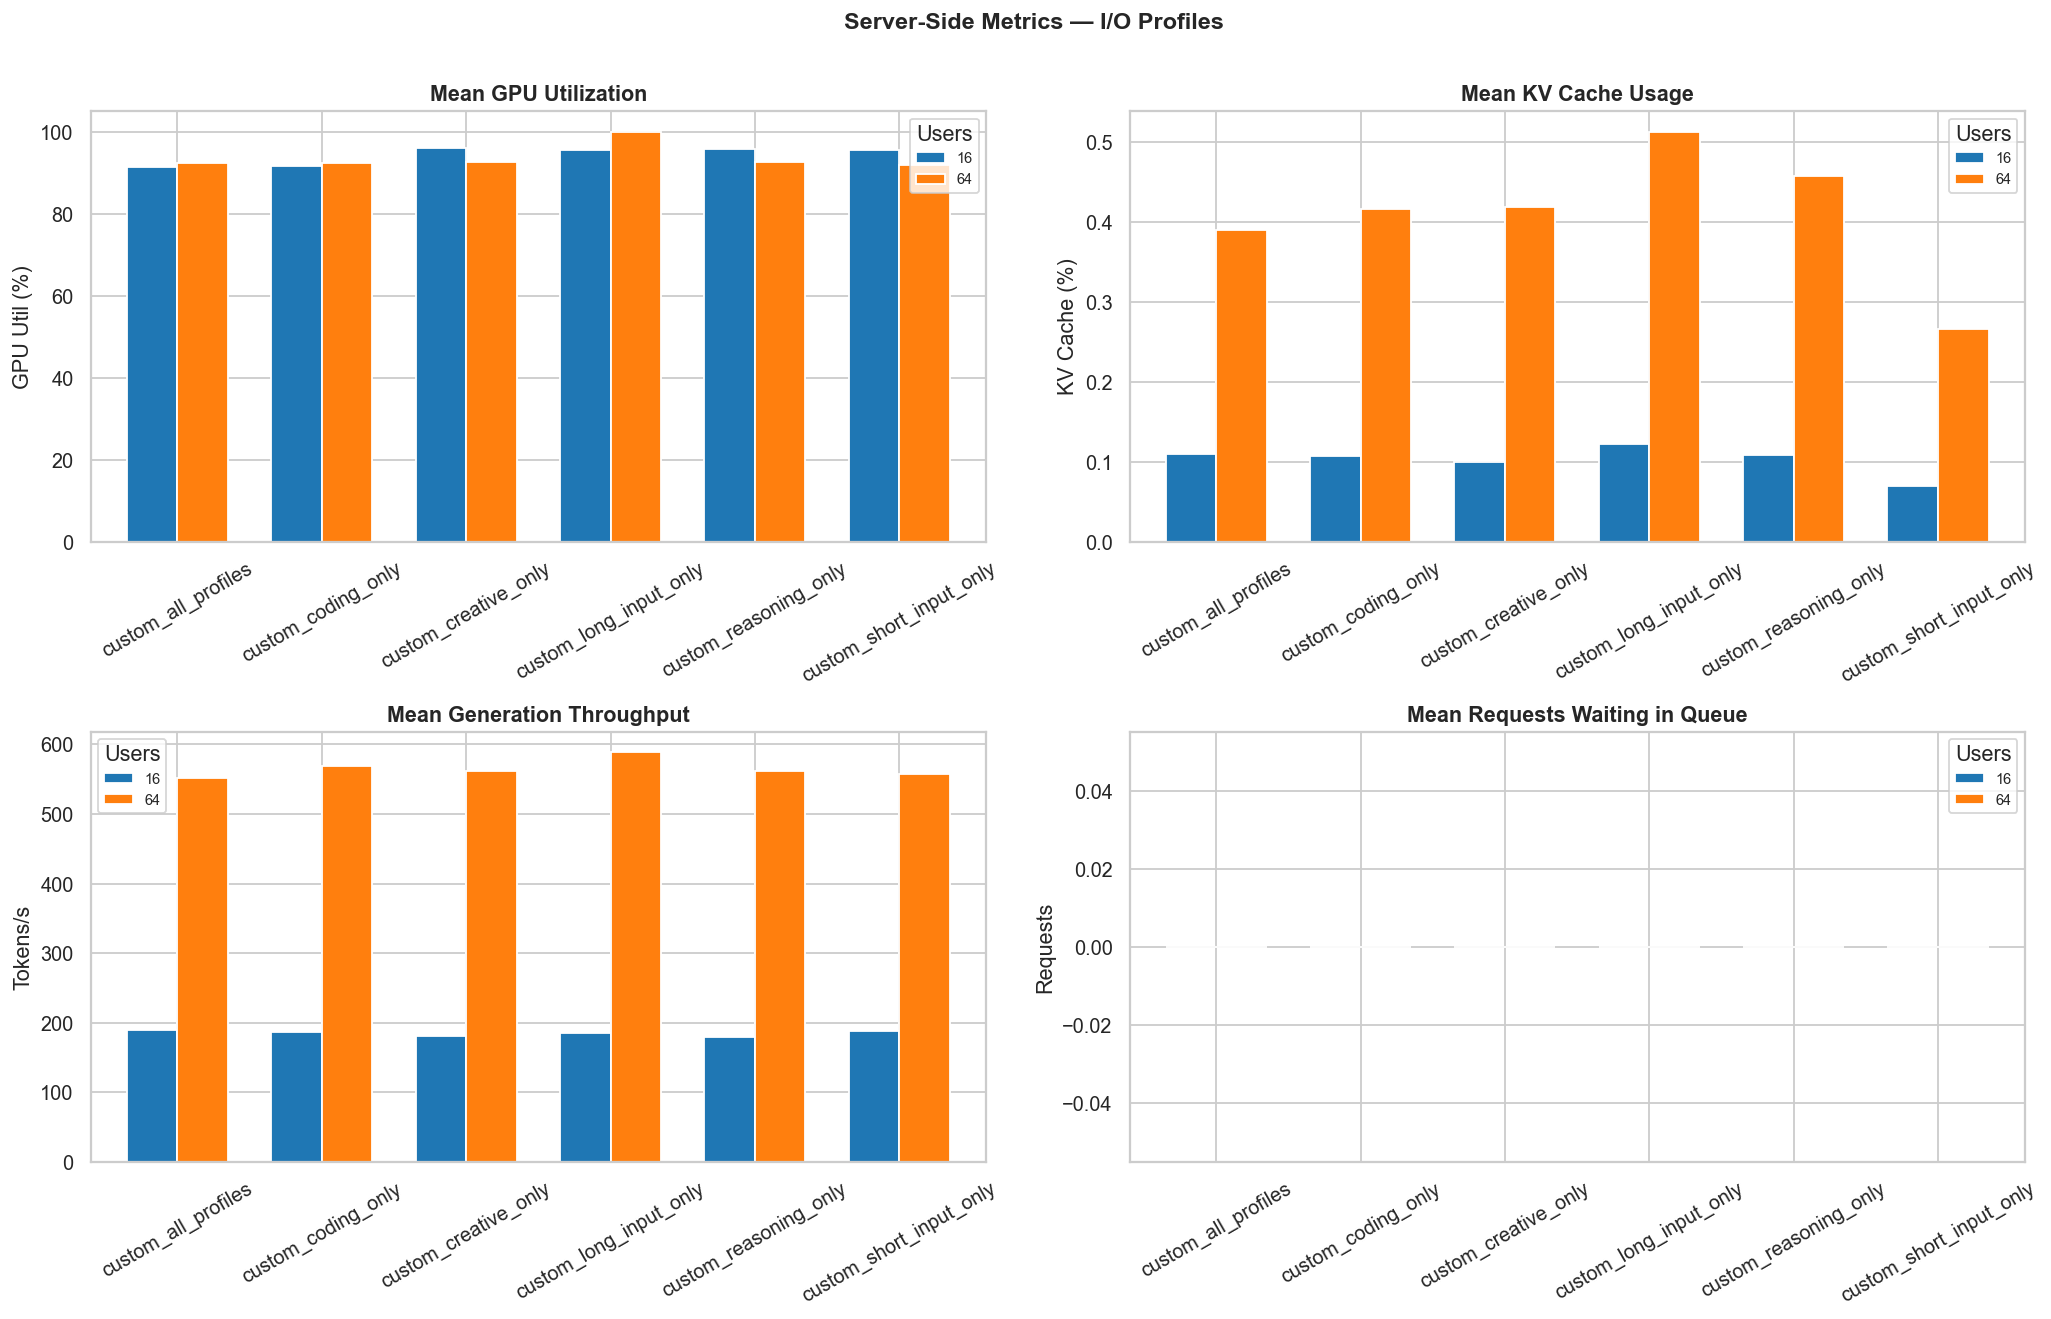

In [21]:
# ─── GPU Utilization & KV Cache: I/O Profiles ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_prom_comparison(pw_io, 'gpu_util_pct', 'GPU Util (%)', 'Mean GPU Utilization', axes[0, 0])
plot_prom_comparison(pw_io, 'kv_cache_usage_pct', 'KV Cache (%)', 'Mean KV Cache Usage', axes[0, 1])
plot_prom_comparison(pw_io, 'generation_tokens_per_sec', 'Tokens/s', 'Mean Generation Throughput', axes[1, 0])
plot_prom_comparison(pw_io, 'requests_waiting', 'Requests', 'Mean Requests Waiting in Queue', axes[1, 1])

plt.suptitle('Server-Side Metrics — I/O Profiles', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

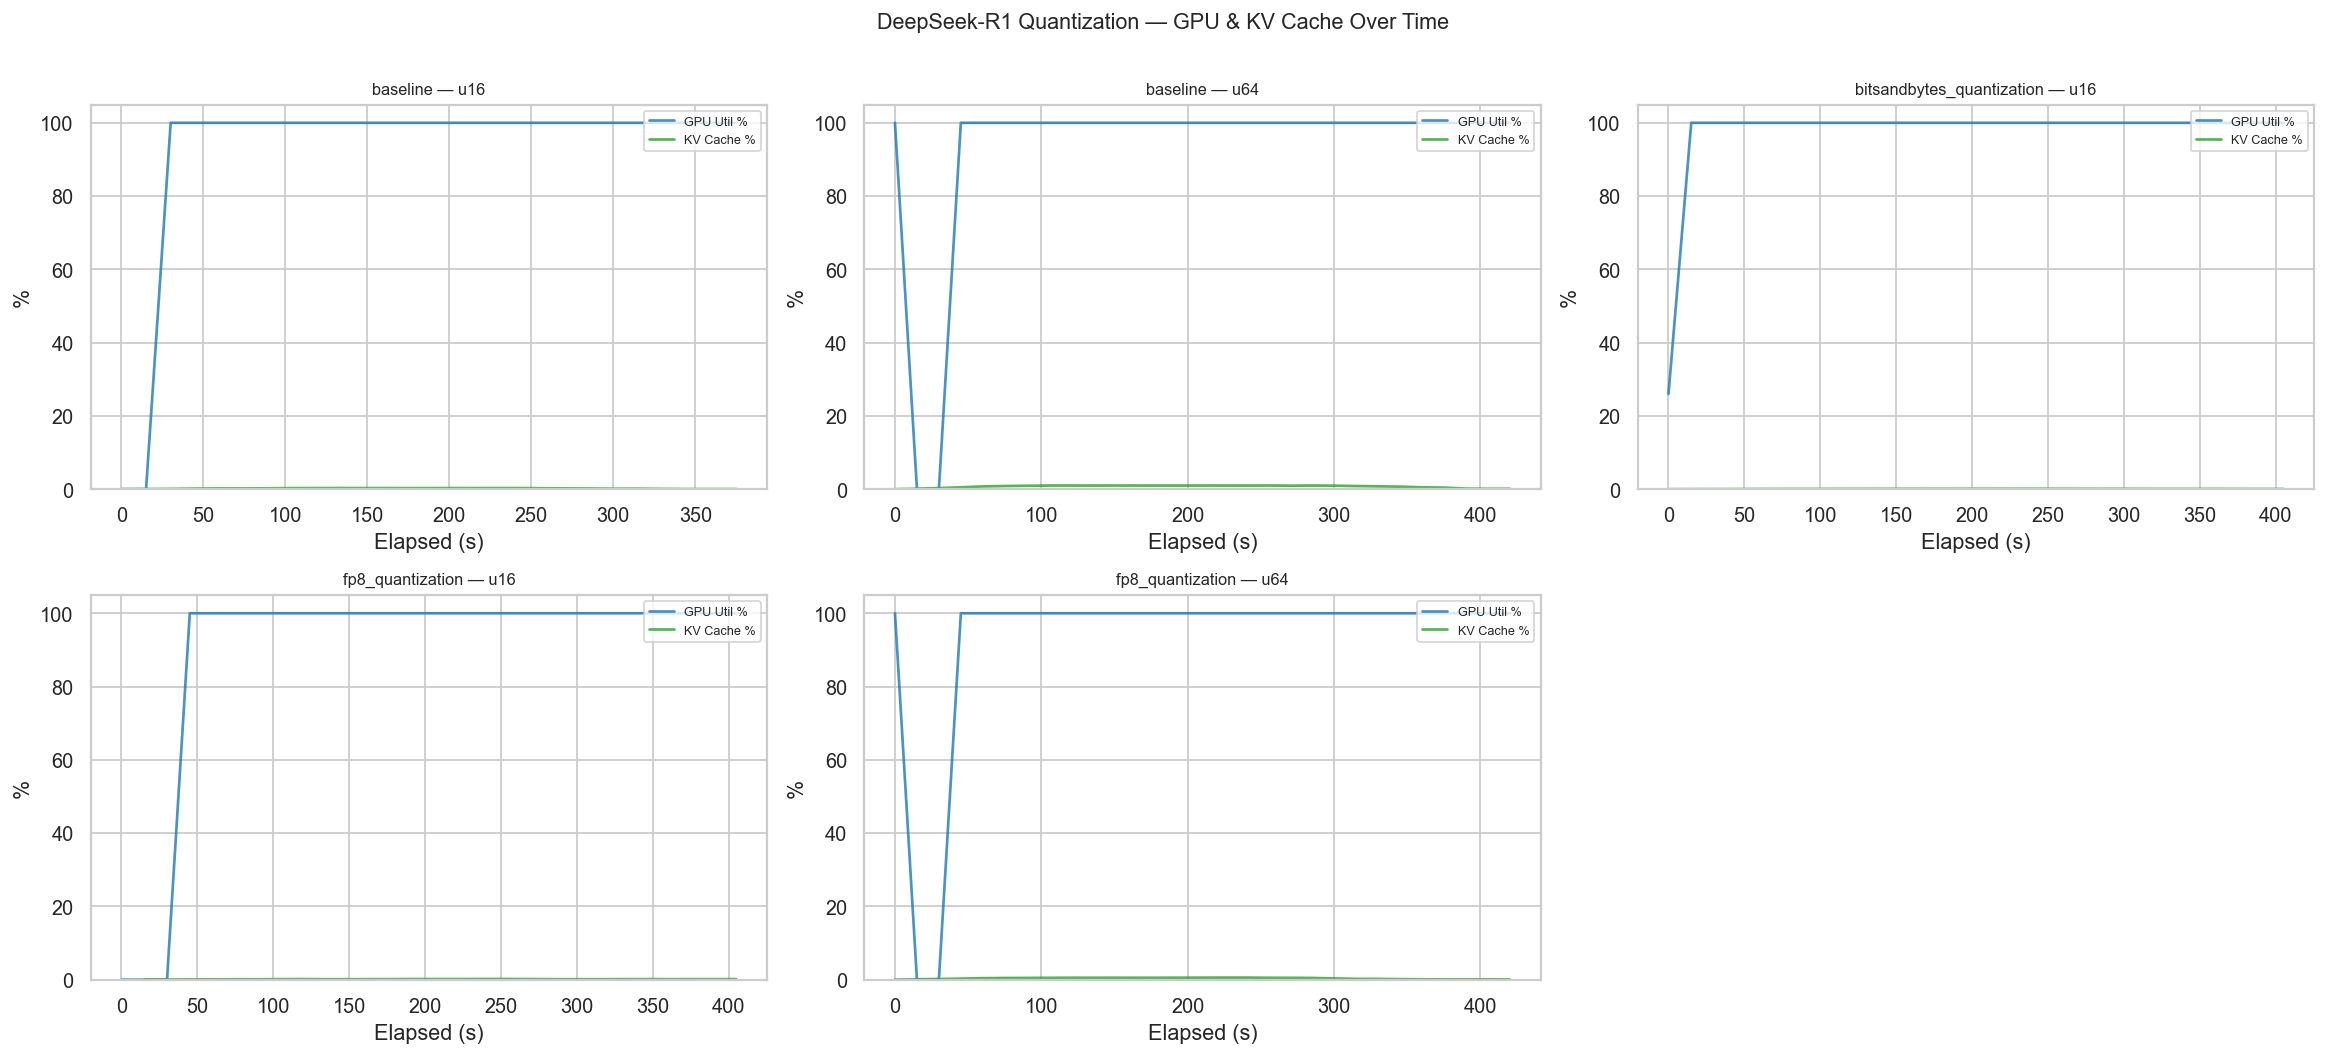

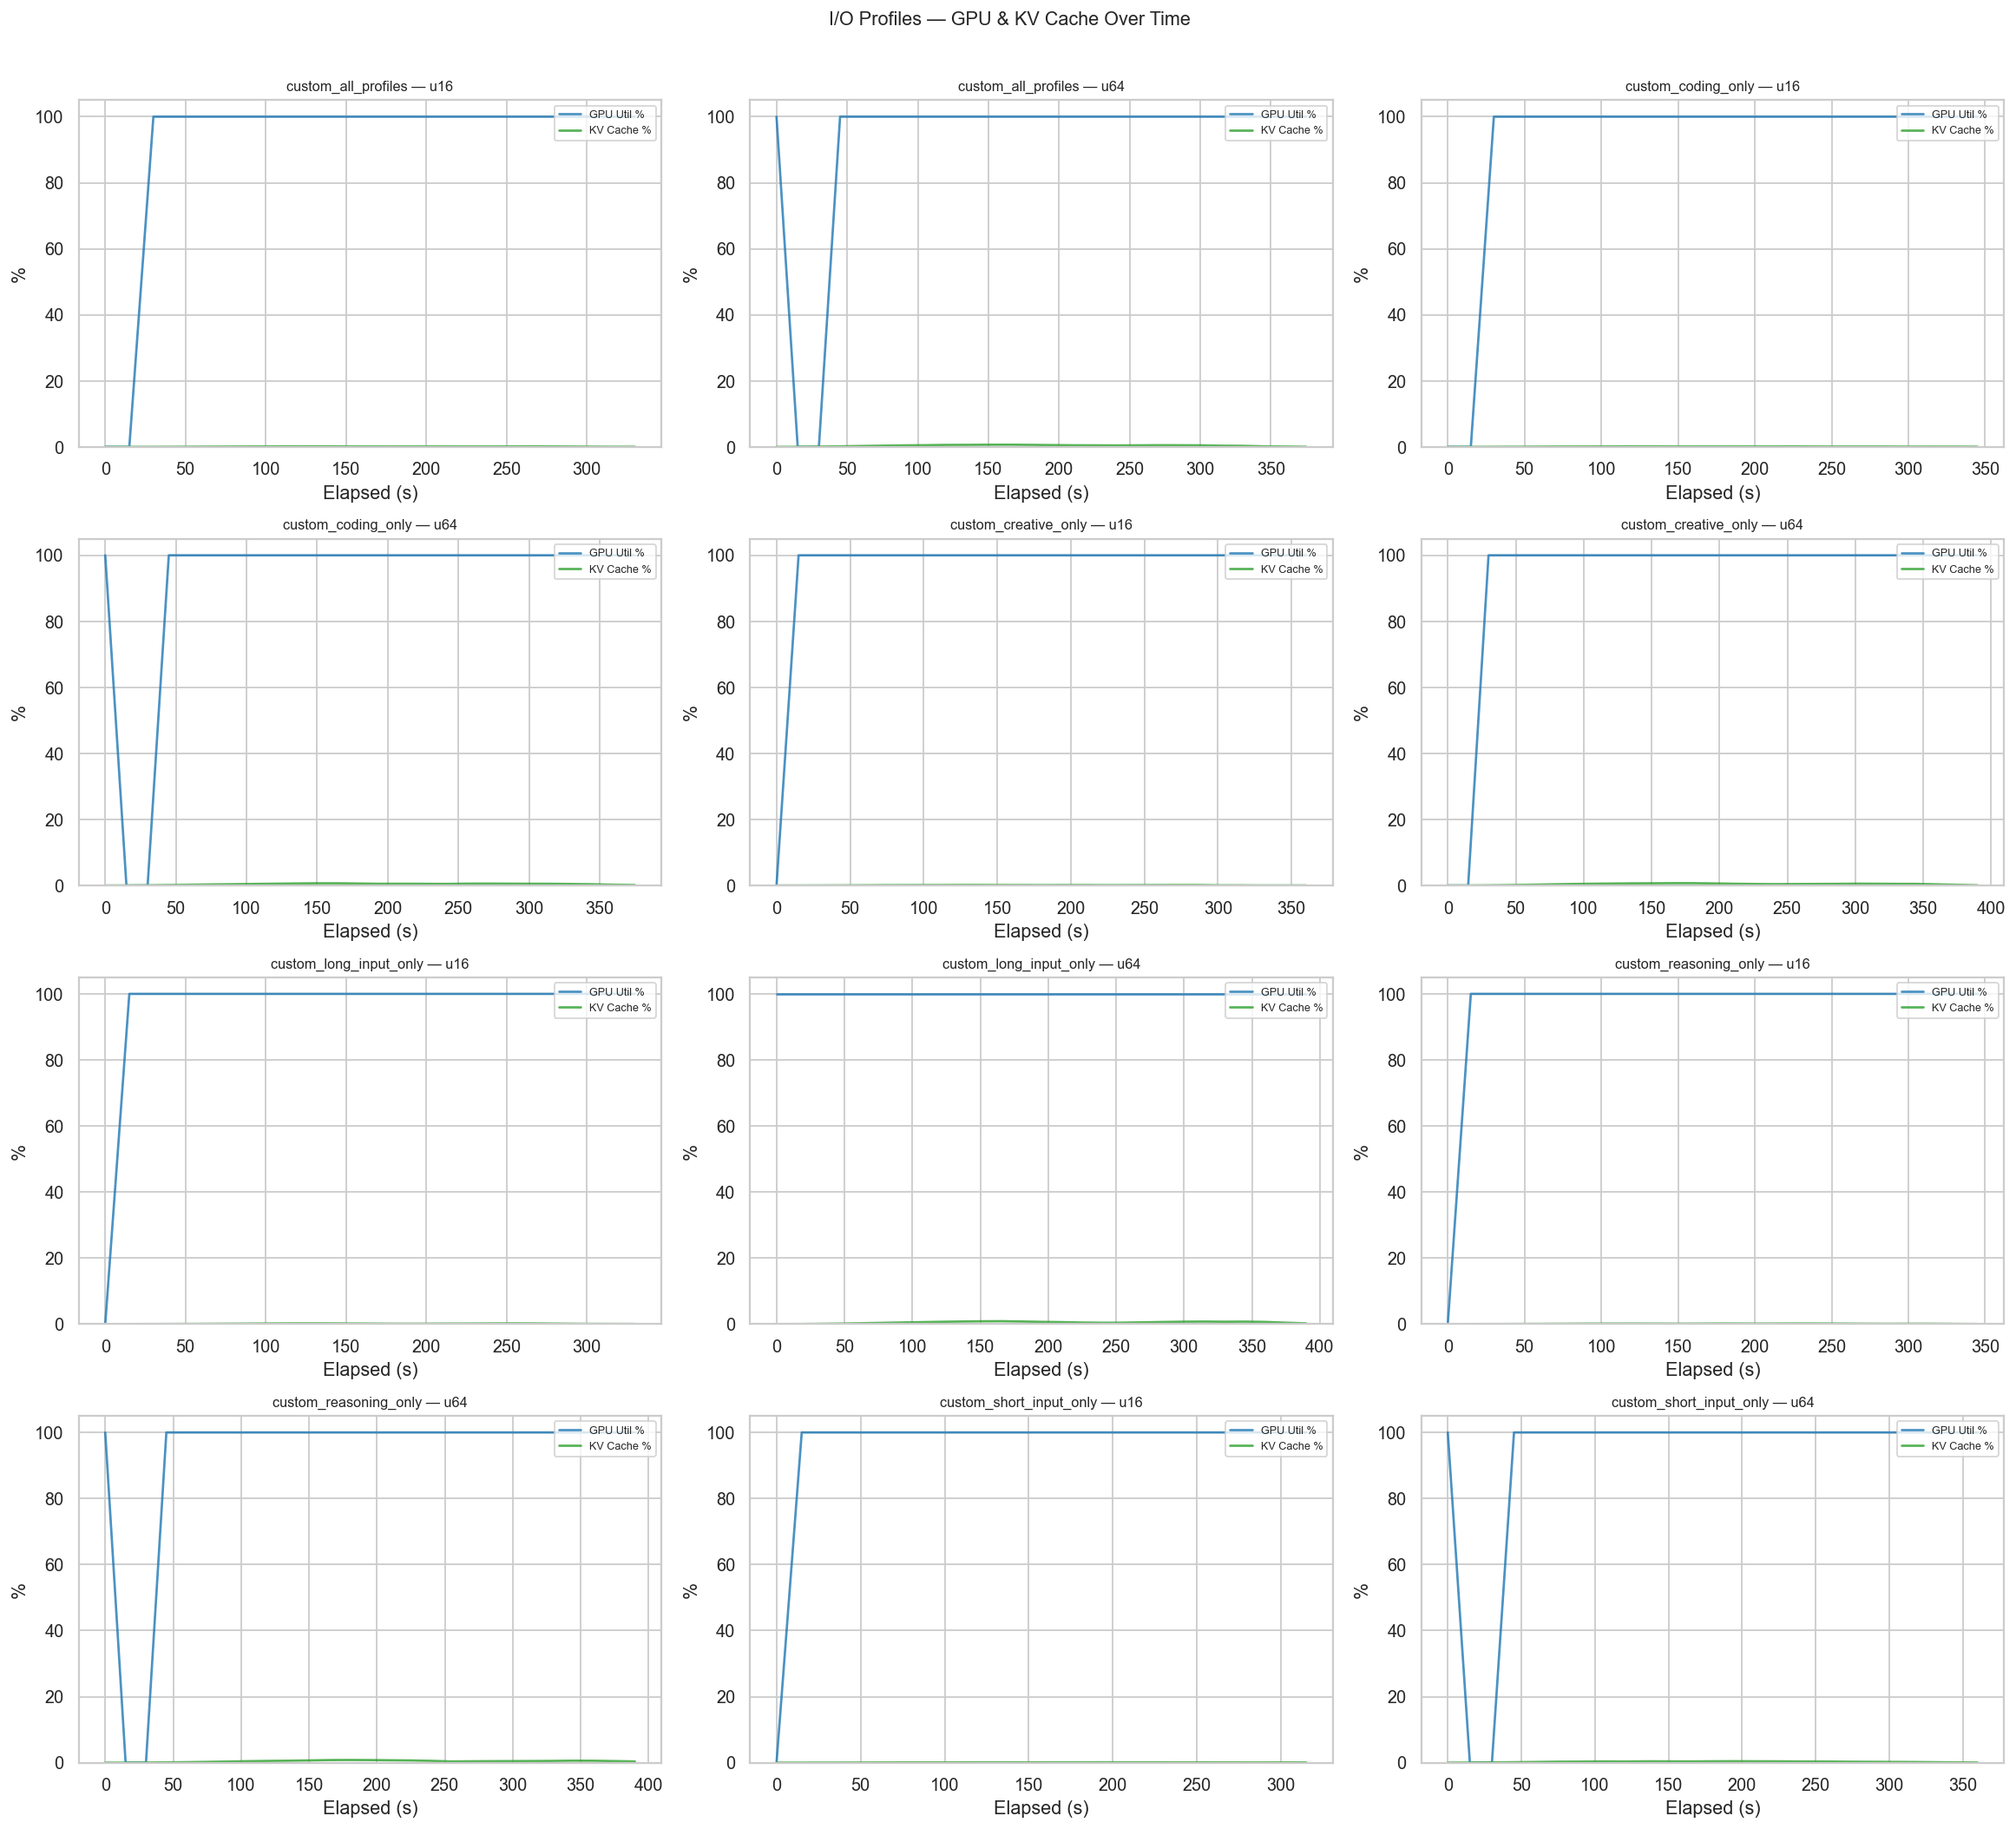

In [22]:
# ─── Prometheus Time Series: KV Cache & GPU for each experiment ───────────────
def plot_prom_timeseries(pw_df, title_prefix):
    if pw_df.empty:
        print(f'⚠ No prometheus data for {title_prefix}')
        return
    combos = list(pw_df.groupby(['experiment', 'users']).groups.keys())
    n = len(combos)
    if n == 0:
        return

    n_cols = min(3, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, (exp, u) in enumerate(combos):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        grp = pw_df[(pw_df['experiment'] == exp) & (pw_df['users'] == u)].sort_values('timestamp')
        t0 = grp['timestamp'].min()
        elapsed = (grp['timestamp'] - t0)

        if 'gpu_util_pct' in grp.columns:
            ax.plot(elapsed, grp['gpu_util_pct'], color='tab:blue', alpha=0.8, label='GPU Util %')
        if 'kv_cache_usage_pct' in grp.columns:
            ax.plot(elapsed, grp['kv_cache_usage_pct'], color='tab:green', alpha=0.8, label='KV Cache %')

        ax.set_ylim(0, 105)
        ax.set_ylabel('%')
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — u{u}', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')

    for i in range(idx + 1, len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle(f'{title_prefix} — GPU & KV Cache Over Time', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

plot_prom_timeseries(pw_qr, 'DeepSeek-R1 Quantization')
plot_prom_timeseries(pw_io, 'I/O Profiles')

---
# Part 6 — Throughput & Cost Efficiency

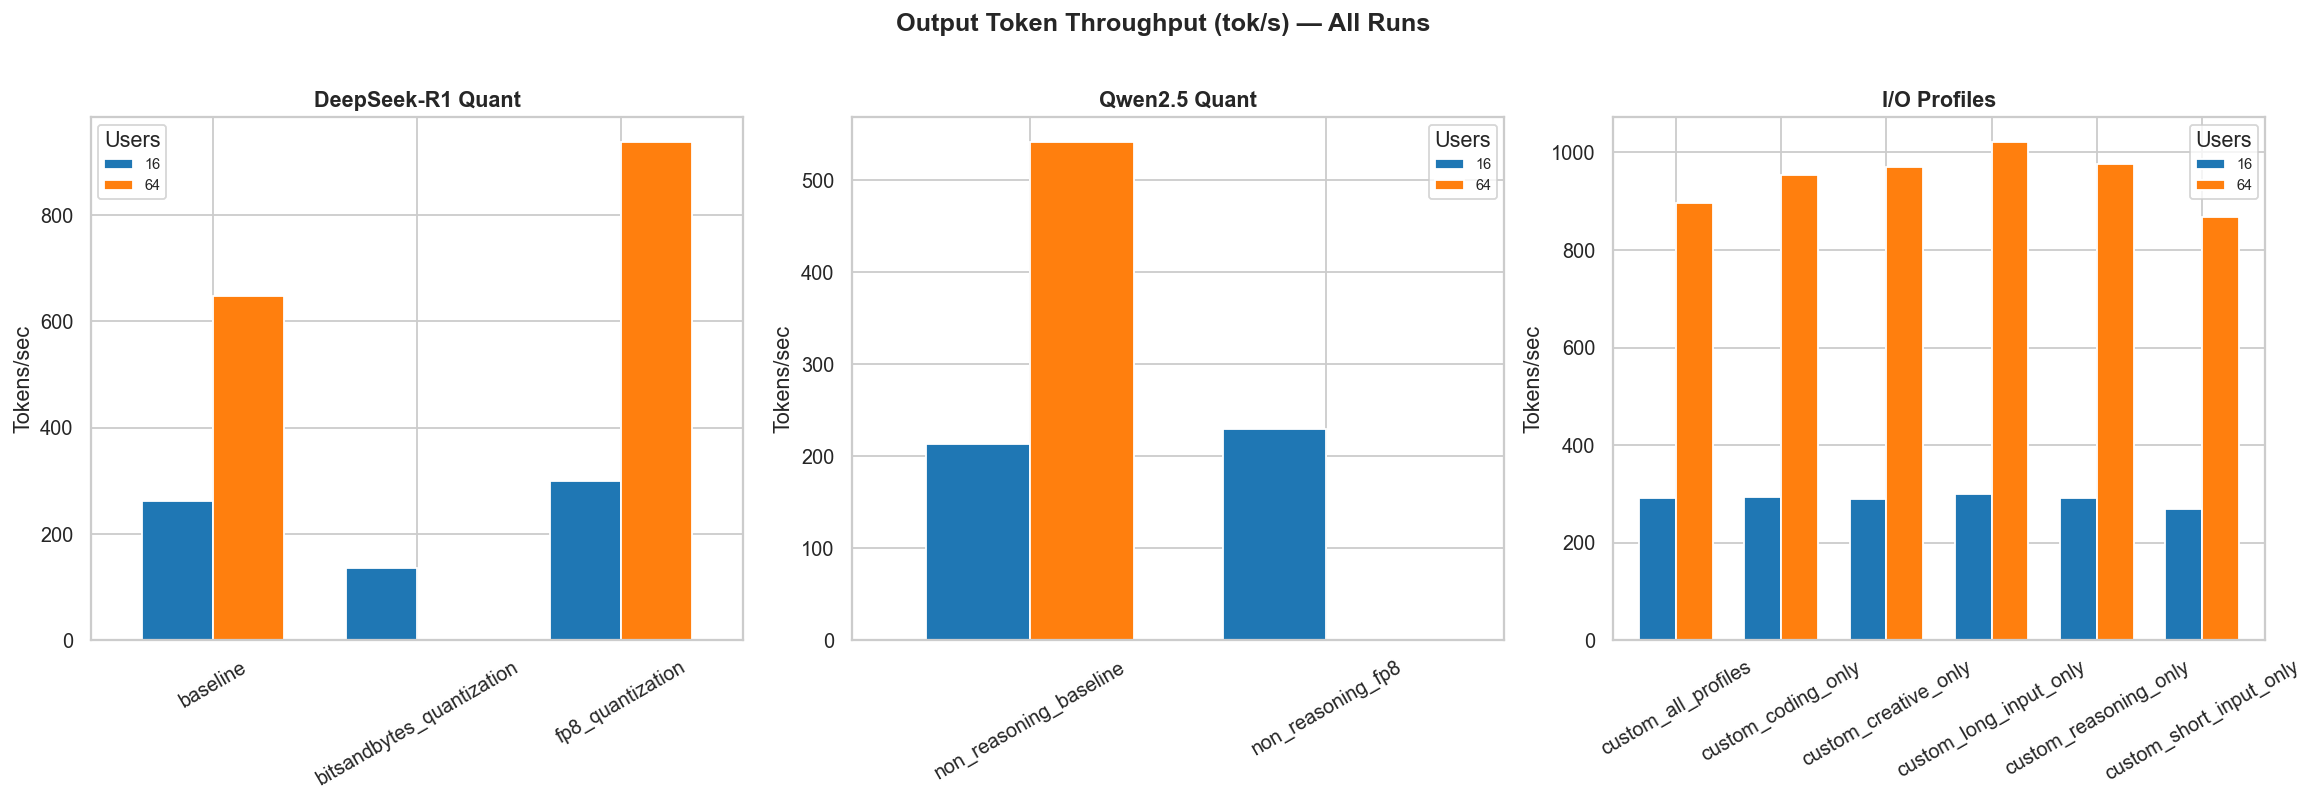

In [23]:
# ─── Throughput & Cost: All 3 runs ────────────────────────────────────────────
def compute_throughput_and_cost(df, run_label):
    ok = df[df['success'] == True].copy()
    rows = []
    for (exp, users), grp in ok.groupby(['experiment', 'users']):
        total_tokens = grp['output_tokens'].sum()
        duration_s   = grp['timestamp'].max() - grp['timestamp'].min()
        if duration_s < 1 or total_tokens == 0:
            continue
        duration_hr  = duration_s / 3600
        tok_per_s    = total_tokens / duration_s
        cost_per_m   = (GPU_HOURLY_COST_USD * duration_hr) / (total_tokens / 1_000_000)
        rows.append({
            'run': run_label, 'experiment': exp, 'users': users,
            'total_tokens': total_tokens, 'duration_s': duration_s,
            'tokens_per_sec': tok_per_s, 'cost_per_M_tokens': cost_per_m,
        })
    return pd.DataFrame(rows)

cost_qr  = compute_throughput_and_cost(df_quant_r,  'DeepSeek-R1 Quant')
cost_qnr = compute_throughput_and_cost(df_quant_nr, 'Qwen2.5 Quant')
cost_io  = compute_throughput_and_cost(df_io,       'I/O Profiles')

cost_all = pd.concat([cost_qr, cost_qnr, cost_io], ignore_index=True)

# Throughput bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (run_label, cost_subset) in zip(axes, [
    ('DeepSeek-R1 Quant', cost_qr),
    ('Qwen2.5 Quant', cost_qnr),
    ('I/O Profiles', cost_io),
]):
    if cost_subset.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(run_label)
        continue
    pivot = cost_subset.pivot(index='experiment', columns='users', values='tokens_per_sec')
    pivot.plot(kind='bar', ax=ax, width=0.7)
    ax.set_ylabel('Tokens/sec')
    ax.set_title(run_label, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Users', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Output Token Throughput (tok/s) — All Runs', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

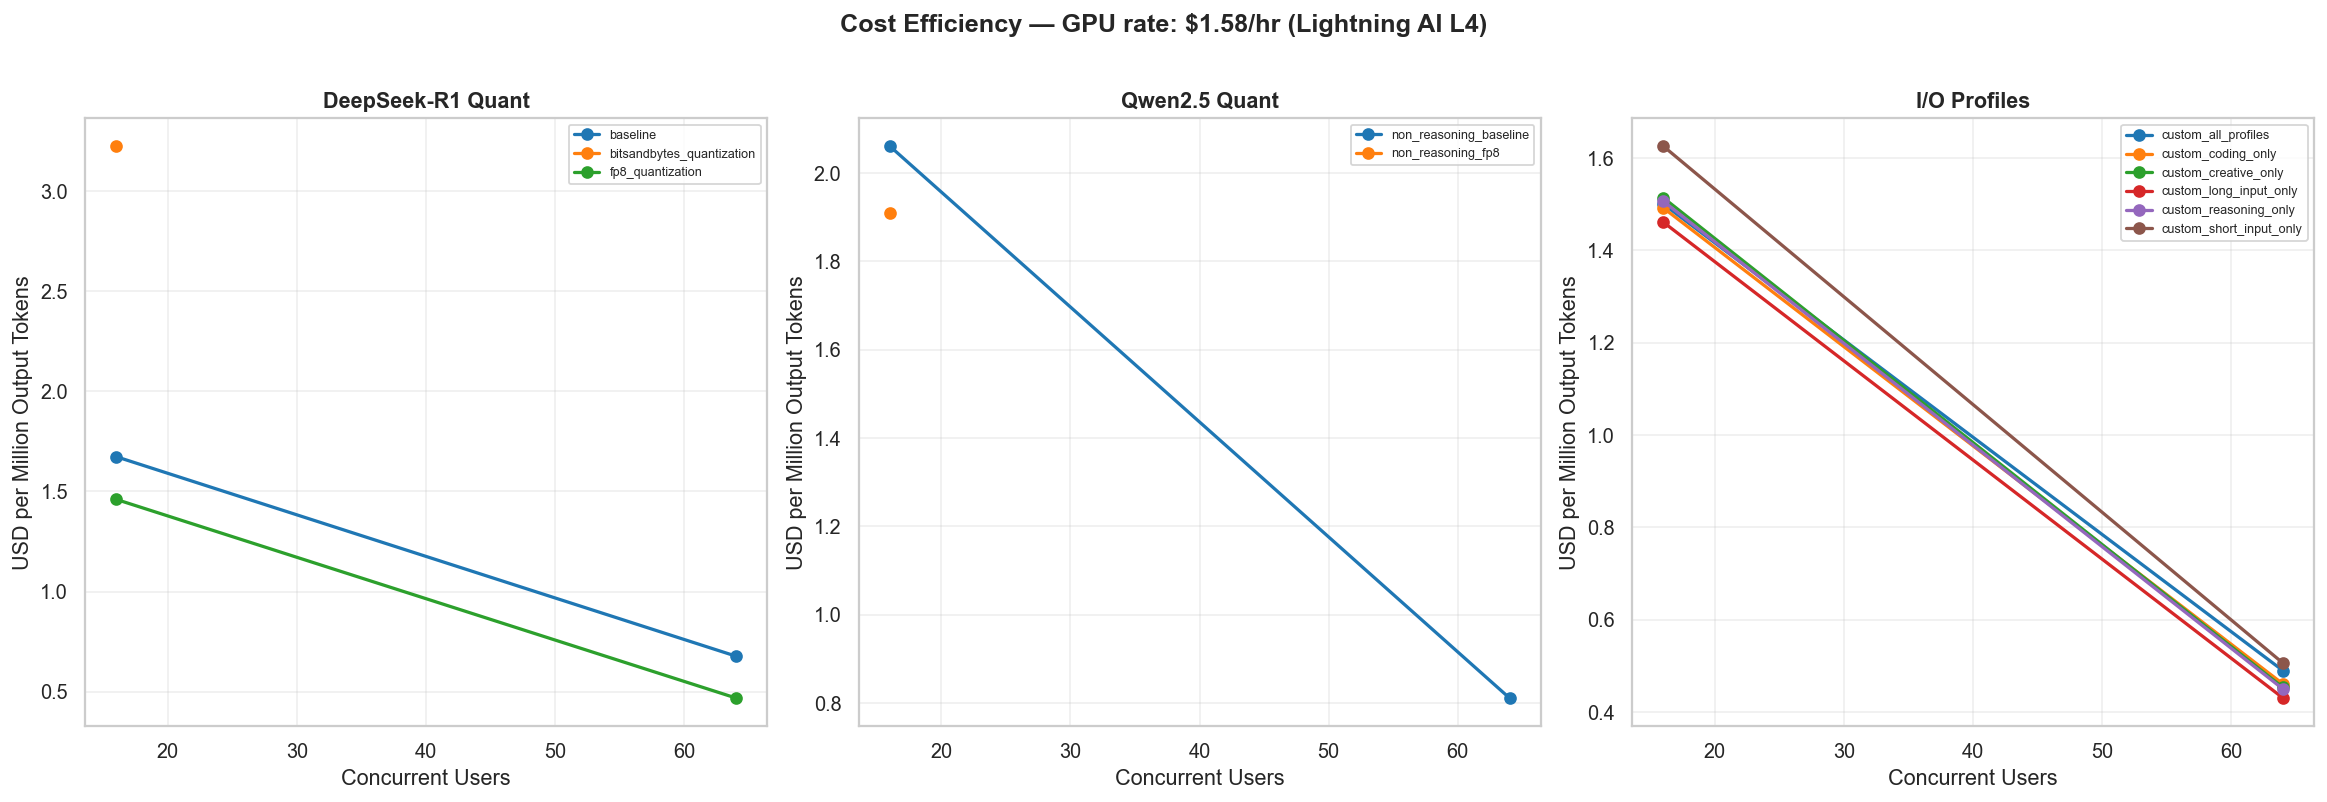

Cost Summary (USD per Million Output Tokens):


,run,experiment,users,total_tokens,duration_s,tokens_per_sec,cost_per_M_tokens
0,DeepSeek-R1 Quant,baseline,16,"58,852",224,262.2,$1.67
1,DeepSeek-R1 Quant,baseline,64,"155,832",241,647.8,$0.68
2,DeepSeek-R1 Quant,bitsandbytes_quantization,16,"26,539",195,136.1,$3.22
3,DeepSeek-R1 Quant,fp8_quantization,16,"70,378",234,300.5,$1.46
4,DeepSeek-R1 Quant,fp8_quantization,64,"225,133",240,936.9,$0.47
5,Qwen2.5 Quant,non_reasoning_baseline,16,"49,461",232,212.9,$2.06
6,Qwen2.5 Quant,non_reasoning_baseline,64,"129,452",239,541.0,$0.81
7,Qwen2.5 Quant,non_reasoning_fp8,16,"54,172",236,229.9,$1.91
8,I/O Profiles,custom_all_profiles,16,"66,186",226,292.4,$1.50
9,I/O Profiles,custom_all_profiles,64,"216,024",241,896.8,$0.49


In [24]:
# ─── Cost Efficiency ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (run_label, cost_subset) in zip(axes, [
    ('DeepSeek-R1 Quant', cost_qr),
    ('Qwen2.5 Quant', cost_qnr),
    ('I/O Profiles', cost_io),
]):
    if cost_subset.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(run_label)
        continue
    for exp in sorted(cost_subset['experiment'].unique()):
        sub = cost_subset[cost_subset['experiment'] == exp]
        ax.plot(sub['users'], sub['cost_per_M_tokens'], marker='o', label=exp, linewidth=1.8)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('USD per Million Output Tokens')
    ax.set_title(f'{run_label}', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Cost Efficiency — GPU rate: ${GPU_HOURLY_COST_USD}/hr (Lightning AI L4)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Cost Summary (USD per Million Output Tokens):')
display(cost_all.style.format({
    'cost_per_M_tokens': '${:.2f}',
    'tokens_per_sec': '{:.1f}',
    'duration_s': '{:.0f}',
    'total_tokens': '{:,}'
}))

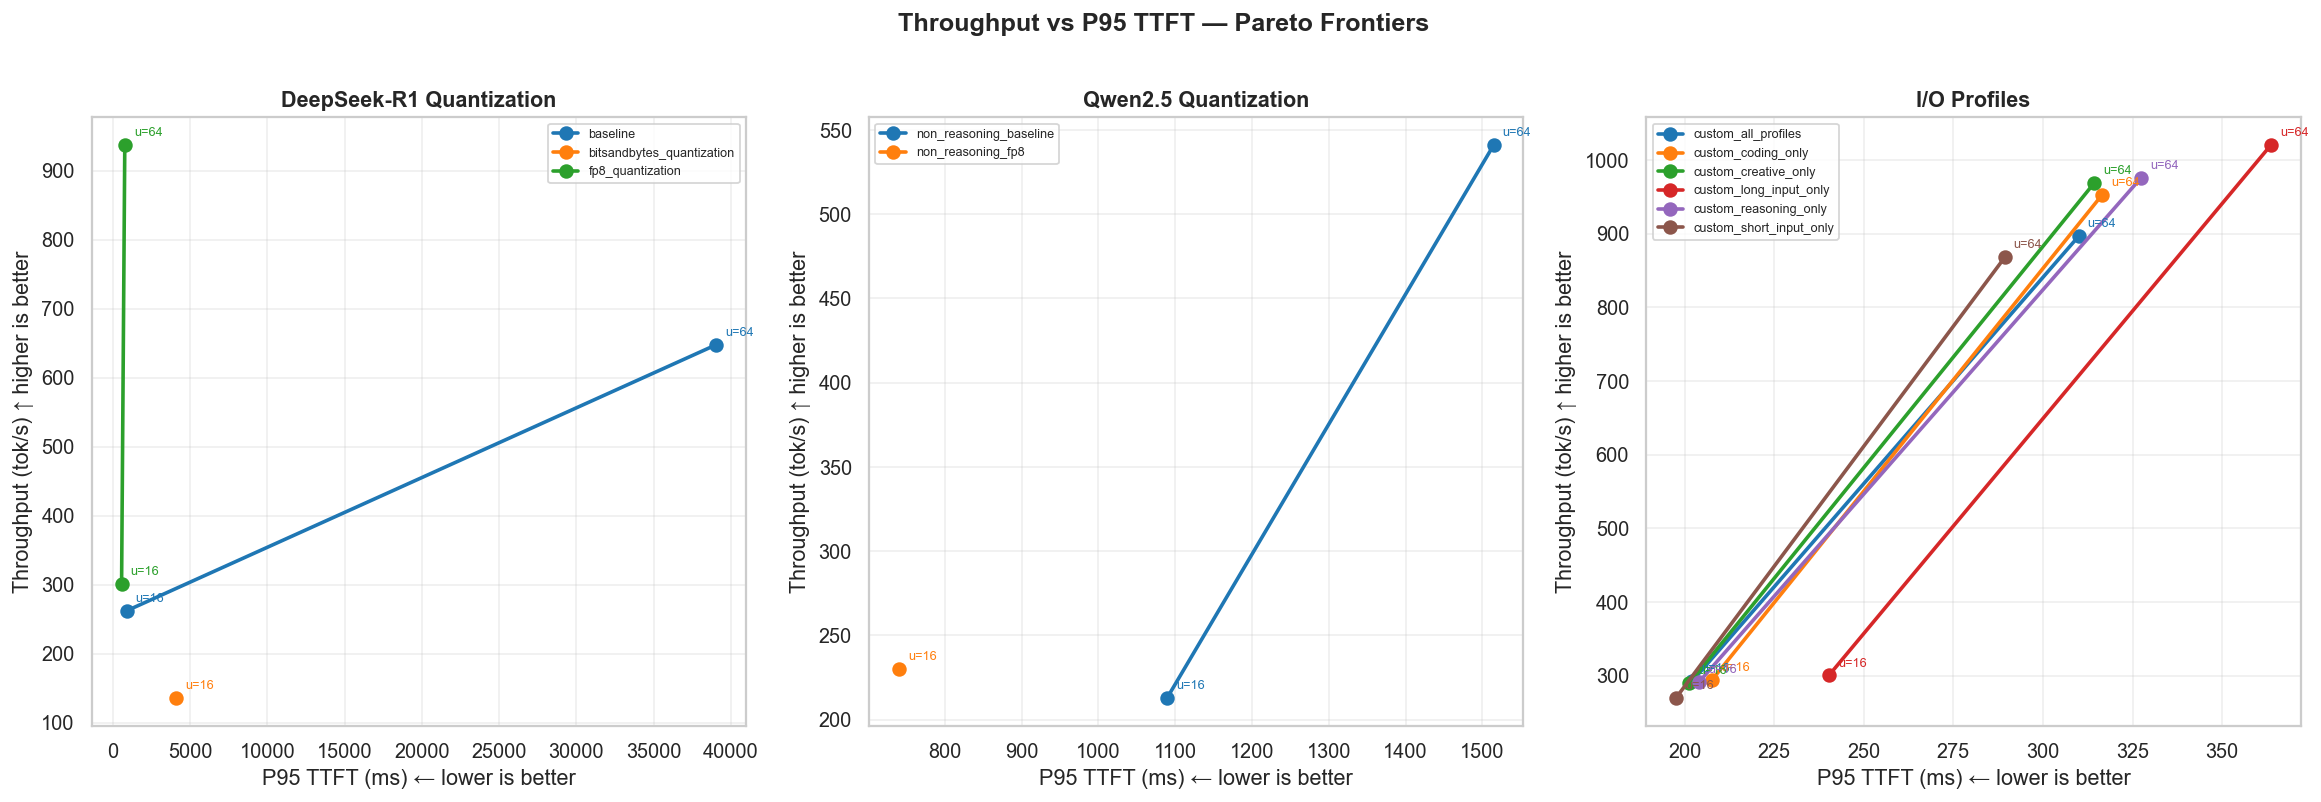

In [25]:
# ─── Throughput vs P95 TTFT — Pareto Frontier (All Runs) ─────────────────────
def compute_pareto(df, run_label):
    ok = df[df['success'] == True].copy()
    rows = []
    for (exp, users), grp in ok.groupby(['experiment', 'users']):
        total_tokens = grp['output_tokens'].sum()
        duration_s = grp['timestamp'].max() - grp['timestamp'].min()
        if duration_s < 1:
            continue
        rows.append({
            'run': run_label, 'experiment': exp, 'users': users,
            'token_throughput': total_tokens / duration_s,
            'ttft_p95': grp['ttft_ms'].quantile(0.95),
        })
    return pd.DataFrame(rows)

pareto_qr = compute_pareto(df_quant_r, 'DeepSeek-R1')
pareto_qnr = compute_pareto(df_quant_nr, 'Qwen2.5')
pareto_io = compute_pareto(df_io, 'I/O Profiles')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, pareto) in zip(axes, [
    ('DeepSeek-R1 Quantization', pareto_qr),
    ('Qwen2.5 Quantization', pareto_qnr),
    ('I/O Profiles', pareto_io),
]):
    if pareto.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(title)
        continue
    palette = sns.color_palette('tab10', pareto['experiment'].nunique())
    for exp, color in zip(sorted(pareto['experiment'].unique()), palette):
        sub = pareto[pareto['experiment'] == exp].sort_values('users')
        ax.plot(sub['ttft_p95'], sub['token_throughput'],
                marker='o', label=exp, color=color, linewidth=2, markersize=7)
        for _, row in sub.iterrows():
            ax.annotate(f'u={int(row["users"])}', (row['ttft_p95'], row['token_throughput']),
                        textcoords='offset points', xytext=(5, 5), fontsize=7, color=color)
    ax.set_xlabel('P95 TTFT (ms) ← lower is better')
    ax.set_ylabel('Throughput (tok/s) ↑ higher is better')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Throughput vs P95 TTFT — Pareto Frontiers', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Part 7 — Quality Evaluation Results (lm-evaluation-harness)

Impact of quantization on model accuracy across ARC-Challenge, MMLU, and GSM8K benchmarks.

In [26]:
# ─── Quality Evaluation: Summary Table ────────────────────────────────────────
# Filter to top-level benchmark results only (not MMLU subtasks)
eval_summary = df_eval[
    (df_eval['task'].isin(['arc_challenge', 'mmlu', 'gsm8k'])) |
    (df_eval['benchmark'] == 'gsm8k')  # gsm8k task name matches
].copy()

# Build clean summary
eval_clean = []
for _, row in eval_summary.iterrows():
    benchmark = row['benchmark']
    if benchmark == 'gsm8k':
        score = row.get('exact_match', np.nan)
        metric_name = 'exact_match (strict)'
    elif benchmark == 'arc_challenge':
        score = row.get('acc_norm', row.get('acc', np.nan))
        metric_name = 'acc_norm'
    else:  # mmlu
        score = row.get('acc', np.nan)
        metric_name = 'acc'
    eval_clean.append({
        'model': row['model'],
        'quantization': row['quantization'],
        'benchmark': benchmark,
        'score': score,
        'metric': metric_name,
    })

df_eval_clean = pd.DataFrame(eval_clean)
df_eval_clean = df_eval_clean.dropna(subset=['score'])

# Pretty label for quantization
quant_labels = {'noquantization': 'No Quant (FP16)', 'fp8': 'FP8', 'bitsandbytes': 'BitsAndBytes'}
df_eval_clean['quant_label'] = df_eval_clean['quantization'].map(quant_labels)

# Pivot table
eval_pivot = df_eval_clean.pivot_table(
    index=['model', 'quant_label'],
    columns='benchmark',
    values='score',
    aggfunc='first'
)

pd.set_option('display.float_format', '{:.3f}'.format)
print('Quality Evaluation Summary (higher is better):')
display(eval_pivot)

Quality Evaluation Summary (higher is better):


benchmark                    arc_challenge  gsm8k  mmlu
model       quant_label                                
DeepSeek-R1 BitsAndBytes             0.516    NaN 0.593
            FP8                      0.518  0.785 0.579
            No Quant (FP16)          0.526  0.800 0.593
Qwen2.5     BitsAndBytes             0.644  0.861   NaN
            FP8                      0.670  0.879 0.779
            No Quant (FP16)          0.662  0.881 0.782

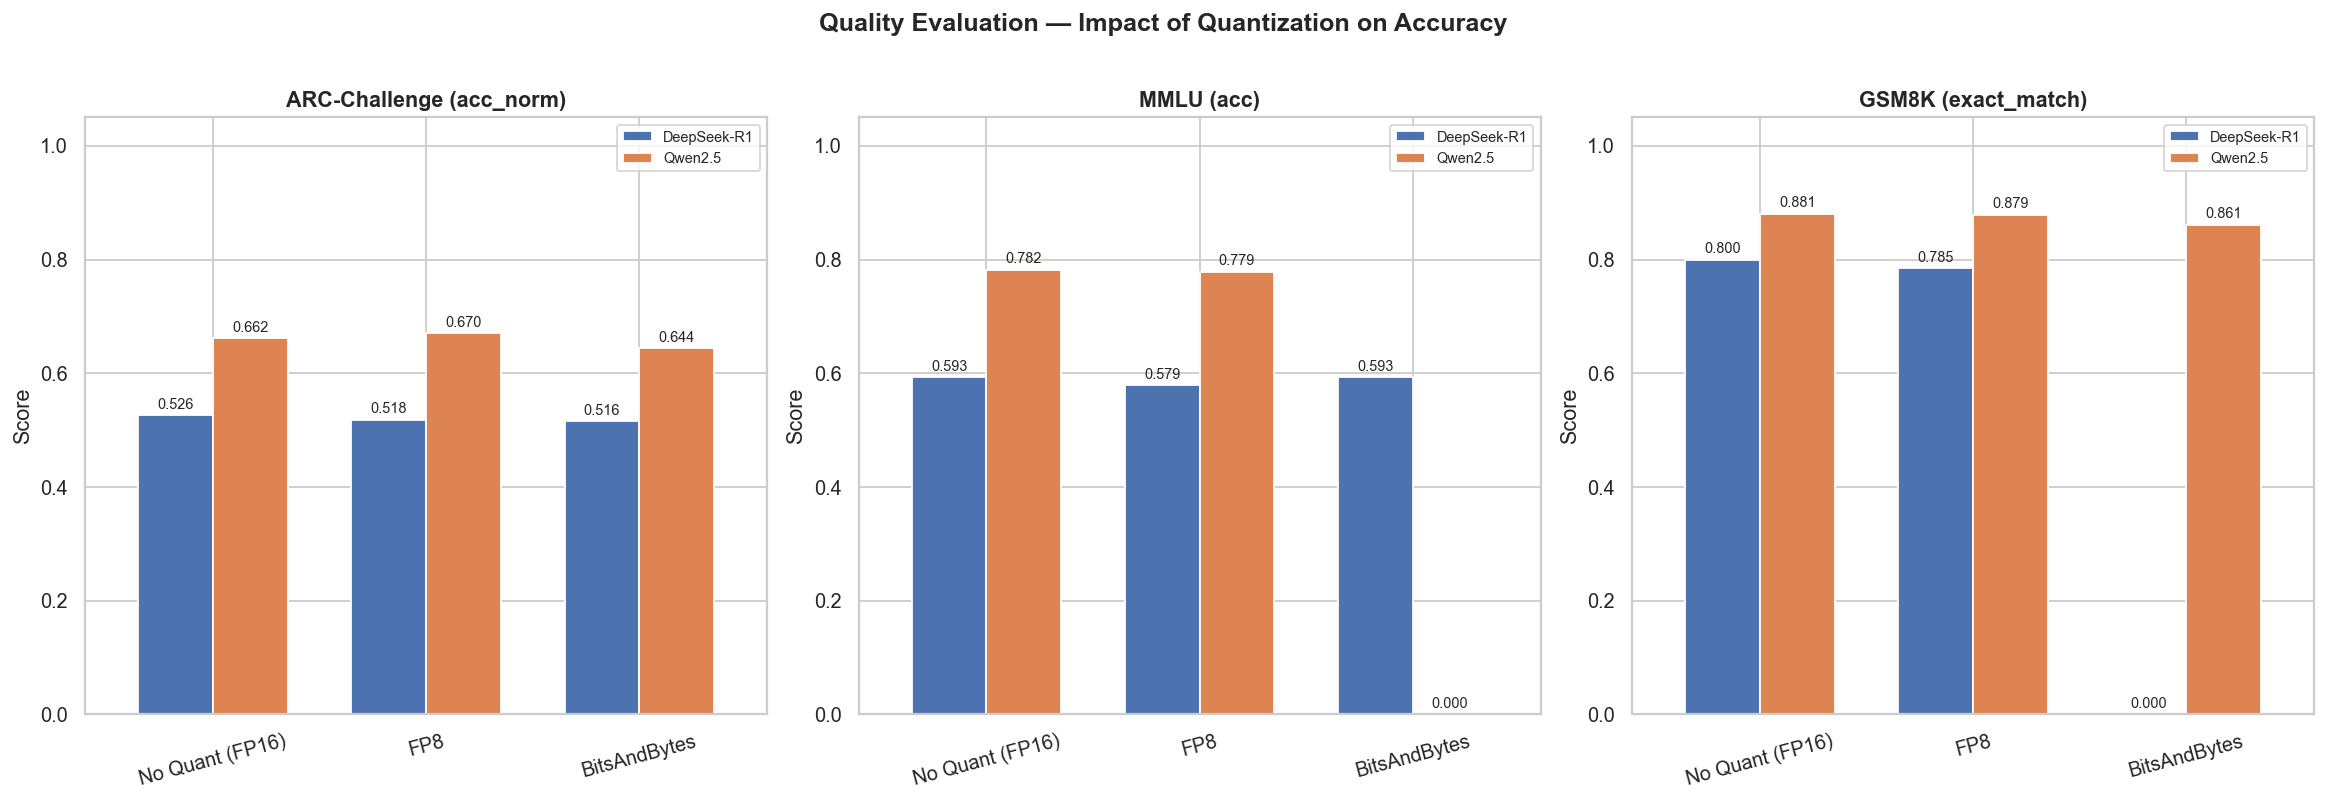

In [27]:
# ─── Quality: Grouped Bar Chart per Benchmark ─────────────────────────────────
benchmarks = ['arc_challenge', 'mmlu', 'gsm8k']
benchmark_titles = {'arc_challenge': 'ARC-Challenge (acc_norm)', 'mmlu': 'MMLU (acc)', 'gsm8k': 'GSM8K (exact_match)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

quant_order = ['No Quant (FP16)', 'FP8', 'BitsAndBytes']
colors = {'DeepSeek-R1': '#4C72B0', 'Qwen2.5': '#DD8452'}

for ax, bench in zip(axes, benchmarks):
    sub = df_eval_clean[df_eval_clean['benchmark'] == bench].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(benchmark_titles.get(bench, bench))
        continue

    pivot = sub.pivot_table(index='quant_label', columns='model', values='score', aggfunc='first')
    pivot = pivot.reindex([q for q in quant_order if q in pivot.index])
    pivot.plot(kind='bar', ax=ax, width=0.7, color=[colors.get(m, 'gray') for m in pivot.columns])

    ax.set_title(benchmark_titles.get(bench, bench), fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.suptitle('Quality Evaluation — Impact of Quantization on Accuracy', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

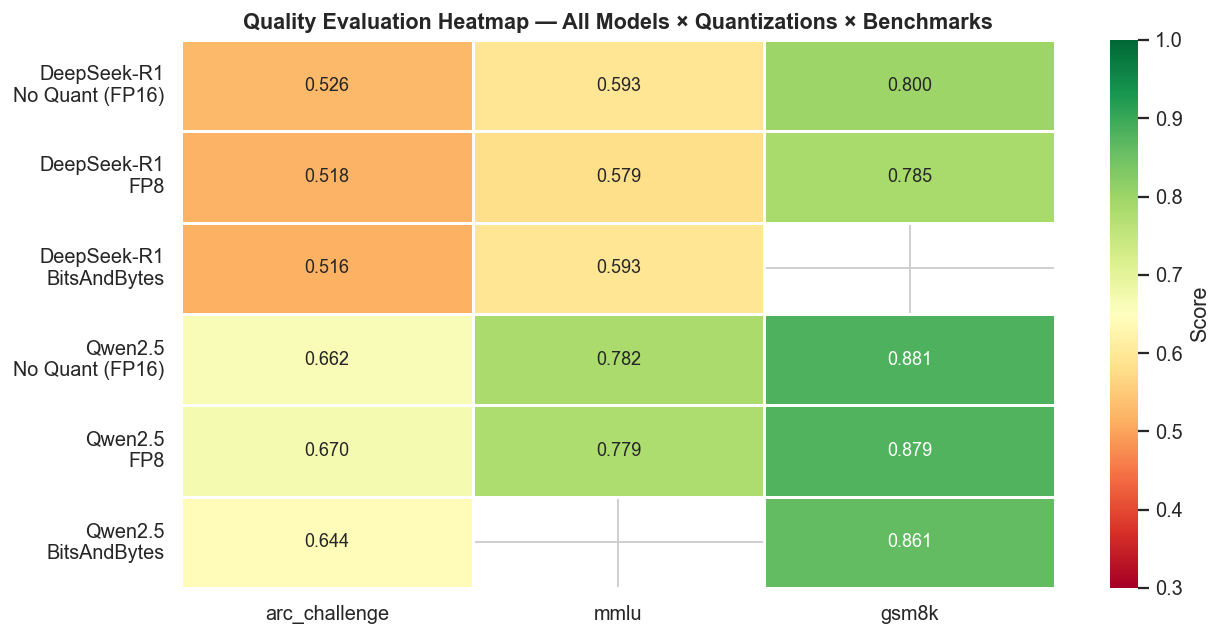

In [28]:
# ─── Quality: Heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

heat_data = df_eval_clean.copy()
heat_data['label'] = heat_data['model'] + '\n' + heat_data['quant_label']
heat_pivot = heat_data.pivot_table(index='label', columns='benchmark', values='score', aggfunc='first')

# Reorder
label_order = []
for model in ['DeepSeek-R1', 'Qwen2.5']:
    for quant in quant_order:
        lbl = f'{model}\n{quant}'
        if lbl in heat_pivot.index:
            label_order.append(lbl)
heat_pivot = heat_pivot.reindex(label_order)
heat_pivot = heat_pivot.reindex(columns=[b for b in benchmarks if b in heat_pivot.columns])

sns.heatmap(heat_pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.3, vmax=1.0,
            linewidths=0.8, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Quality Evaluation Heatmap — All Models × Quantizations × Benchmarks',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Quality Change vs No-Quantization Baseline (negative = degradation):


,model,quantization,benchmark,baseline_score,quant_score,change_pct
0,DeepSeek-R1,FP8,arc_challenge,0.526,0.518,-1.52%
1,DeepSeek-R1,BitsAndBytes,arc_challenge,0.526,0.516,-1.90%
2,DeepSeek-R1,FP8,mmlu,0.593,0.579,-2.37%
3,DeepSeek-R1,BitsAndBytes,mmlu,0.593,0.593,+0.00%
4,DeepSeek-R1,FP8,gsm8k,0.800,0.785,-1.88%
5,Qwen2.5,FP8,arc_challenge,0.662,0.670,+1.21%
6,Qwen2.5,BitsAndBytes,arc_challenge,0.662,0.644,-2.72%
7,Qwen2.5,FP8,mmlu,0.782,0.779,-0.45%
8,Qwen2.5,FP8,gsm8k,0.881,0.879,-0.23%
9,Qwen2.5,BitsAndBytes,gsm8k,0.881,0.861,-2.27%


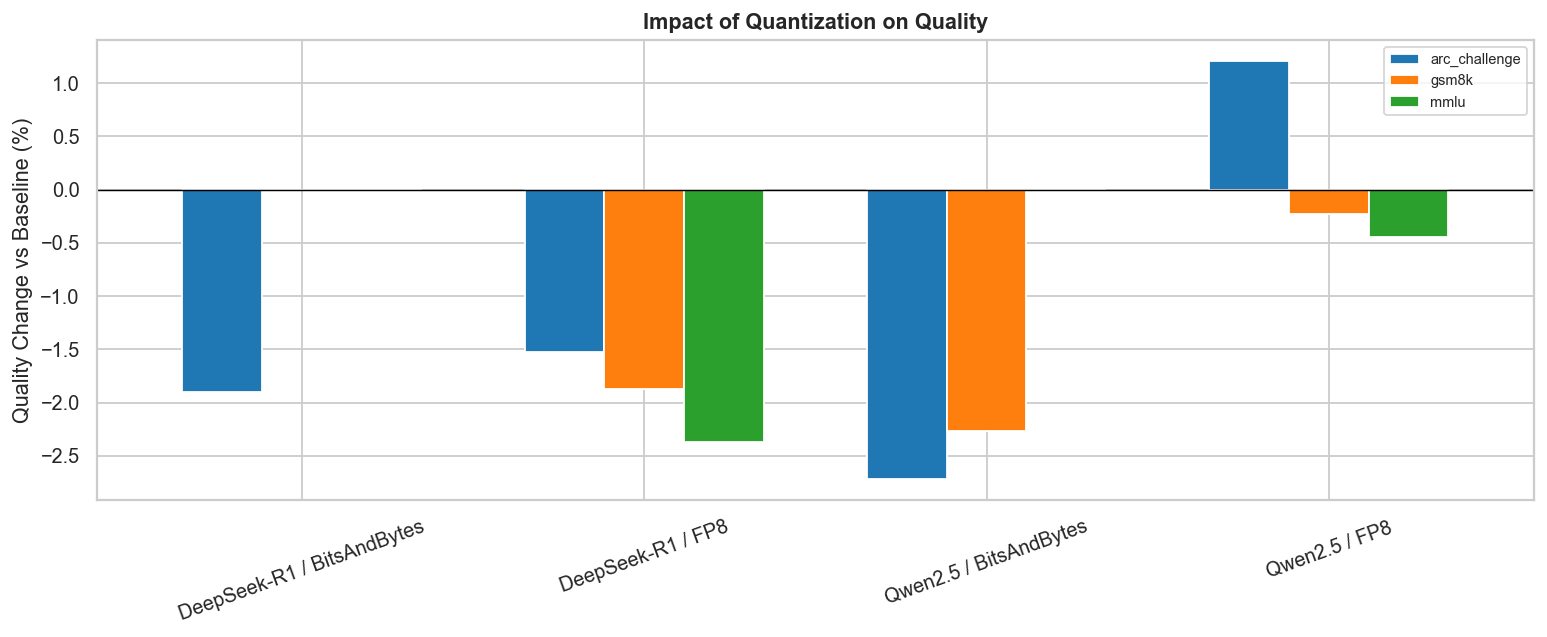

In [29]:
# ─── Quality: Percentage Change from Baseline ─────────────────────────────────
change_rows = []
for model in df_eval_clean['model'].unique():
    for bench in df_eval_clean['benchmark'].unique():
        base = df_eval_clean[
            (df_eval_clean['model'] == model) &
            (df_eval_clean['benchmark'] == bench) &
            (df_eval_clean['quantization'] == 'noquantization')
        ]
        if base.empty:
            continue
        base_score = base.iloc[0]['score']
        if pd.isna(base_score) or base_score == 0:
            continue
        for quant in ['fp8', 'bitsandbytes']:
            comp = df_eval_clean[
                (df_eval_clean['model'] == model) &
                (df_eval_clean['benchmark'] == bench) &
                (df_eval_clean['quantization'] == quant)
            ]
            if comp.empty:
                continue
            comp_score = comp.iloc[0]['score']
            pct_change = (comp_score - base_score) / base_score * 100
            change_rows.append({
                'model': model,
                'quantization': quant_labels.get(quant, quant),
                'benchmark': bench,
                'baseline_score': base_score,
                'quant_score': comp_score,
                'change_pct': pct_change,
            })

df_change = pd.DataFrame(change_rows)
if not df_change.empty:
    print('Quality Change vs No-Quantization Baseline (negative = degradation):')
    display(df_change.style.format({
        'baseline_score': '{:.3f}',
        'quant_score': '{:.3f}',
        'change_pct': '{:+.2f}%',
    }).map(
        lambda v: 'color: green' if isinstance(v, str) and v.startswith('+') else
                  'color: red' if isinstance(v, str) and v.startswith('-') else '',
        subset=['change_pct']
    ))

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    df_change['label'] = df_change['model'] + ' / ' + df_change['quantization']
    pivot_change = df_change.pivot_table(index='label', columns='benchmark', values='change_pct', aggfunc='first')
    pivot_change.plot(kind='bar', ax=ax, width=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Quality Change vs Baseline (%)')
    ax.set_title('Impact of Quantization on Quality', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('⚠ Could not compute quality change — missing baseline data.')

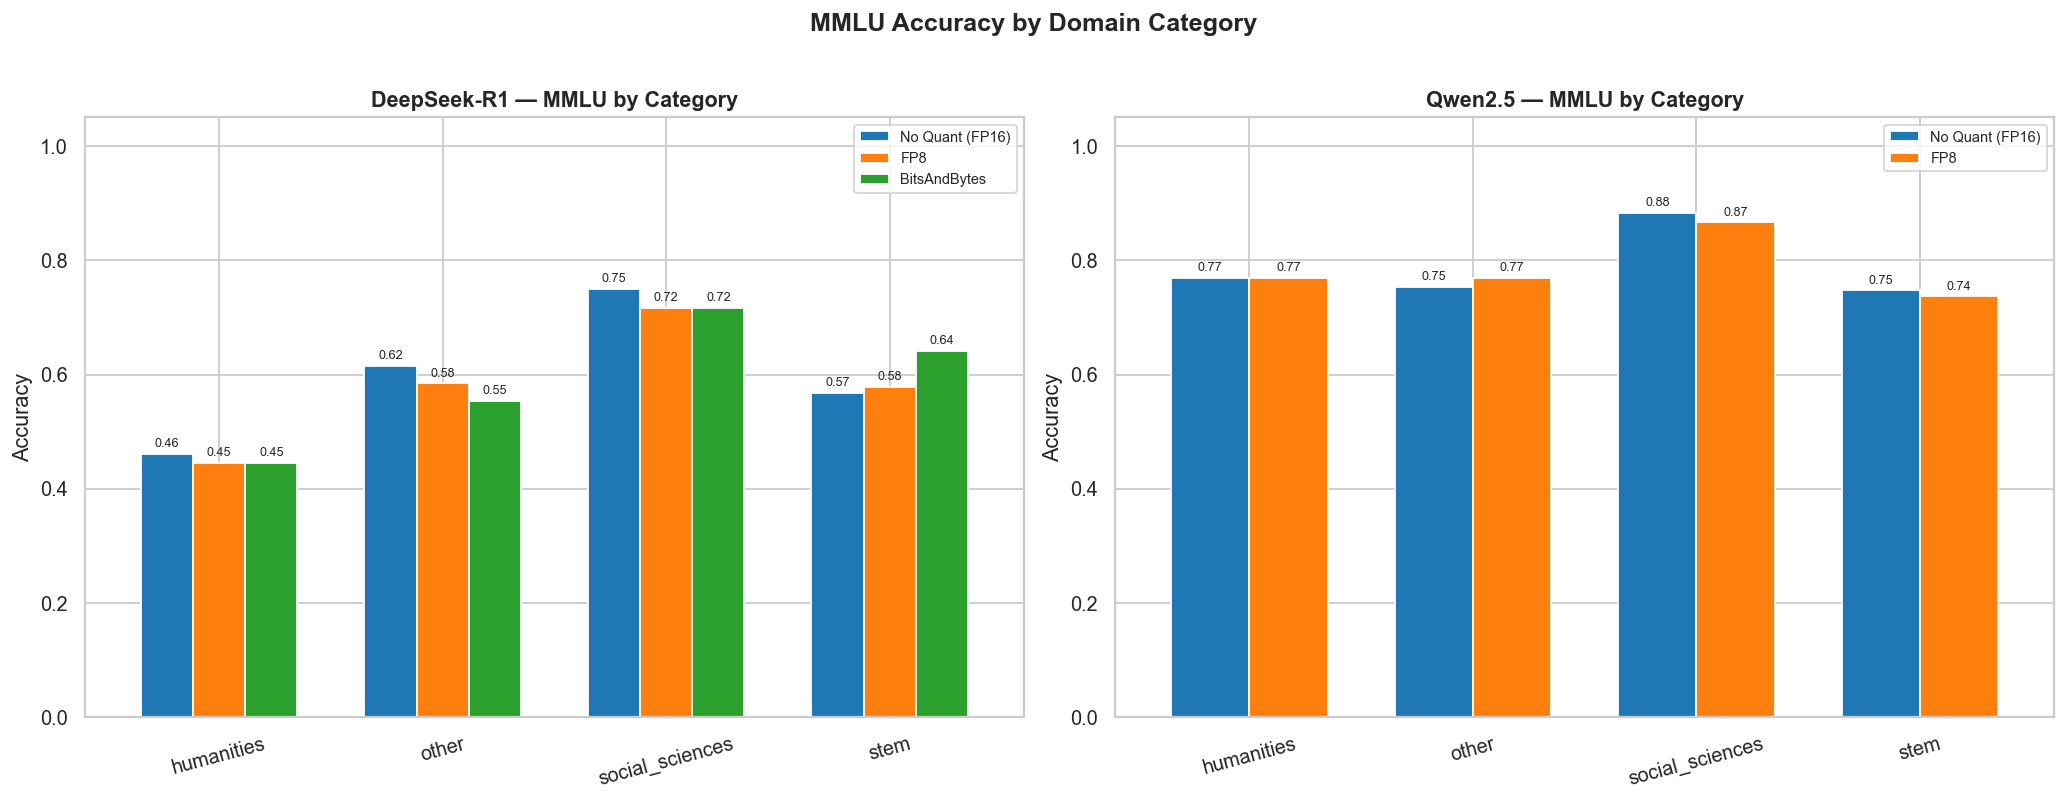

In [30]:
# ─── Quality: MMLU Category Breakdown ─────────────────────────────────────────
mmlu_cats = df_eval[
    (df_eval['benchmark'] == 'mmlu') &
    (df_eval['task'].str.startswith('mmlu_')) &
    (~df_eval['task'].isin(['mmlu_stem', 'mmlu_other', 'mmlu_social_sciences', 'mmlu_humanities']))
].copy()

# Get MMLU category aggregates (stem, other, social_sciences, humanities)
mmlu_groups = df_eval[
    df_eval['task'].isin(['mmlu_stem', 'mmlu_other', 'mmlu_social_sciences', 'mmlu_humanities'])
].copy()

if not mmlu_groups.empty:
    mmlu_groups['quant_label'] = mmlu_groups['quantization'].map(quant_labels)
    mmlu_groups['category'] = mmlu_groups['task'].str.replace('mmlu_', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, model in zip(axes, ['DeepSeek-R1', 'Qwen2.5']):
        sub = mmlu_groups[mmlu_groups['model'] == model]
        if sub.empty:
            ax.text(0.5, 0.5, f'No MMLU category data for {model}', transform=ax.transAxes, ha='center')
            ax.set_title(model)
            continue
        pivot = sub.pivot_table(index='category', columns='quant_label', values='acc', aggfunc='first')
        pivot = pivot.reindex(columns=[q for q in quant_order if q in pivot.columns])
        pivot.plot(kind='bar', ax=ax, width=0.7)
        ax.set_title(f'{model} — MMLU by Category', fontweight='bold')
        ax.set_ylabel('Accuracy')
        ax.set_xlabel('')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=15)
        ax.legend(fontsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=2, fontsize=7)

    plt.suptitle('MMLU Accuracy by Domain Category', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('⚠ No MMLU category-level data available.')

---
# Part 8 — Combined View: Performance vs Quality Trade-off

The ultimate question: is the latency gain from quantization worth the quality loss?

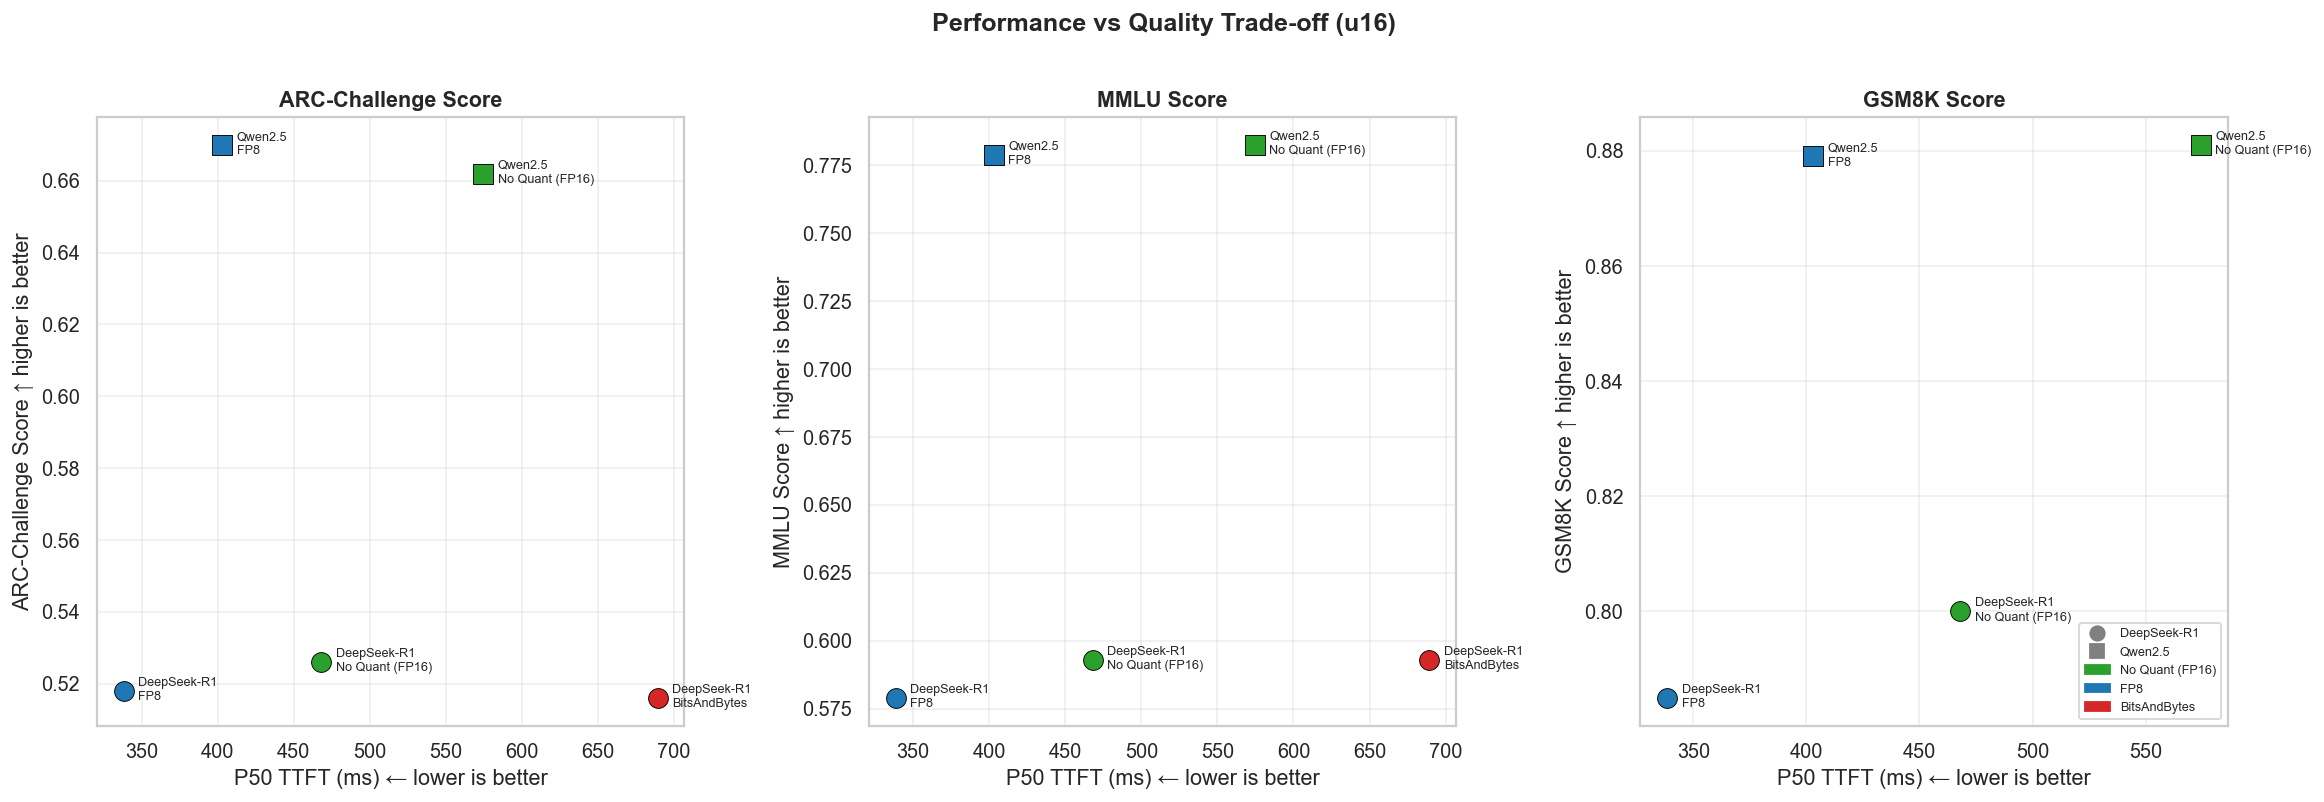

In [31]:
# ─── Performance vs Quality Trade-off ─────────────────────────────────────────
# Map benchmark performance experiments to evaluation quantization labels
perf_to_quant = {
    'baseline': ('DeepSeek-R1', 'noquantization'),
    'fp8_quantization': ('DeepSeek-R1', 'fp8'),
    'bitsandbytes_quantization': ('DeepSeek-R1', 'bitsandbytes'),
    'non_reasoning_baseline': ('Qwen2.5', 'noquantization'),
    'non_reasoning_fp8': ('Qwen2.5', 'fp8'),
}

# Build combined dataframe: perf metrics + quality scores
all_perf = pd.concat([sum_qr, sum_qnr], ignore_index=True)

tradeoff_rows = []
for _, perf_row in all_perf.iterrows():
    exp = perf_row['experiment']
    if exp not in perf_to_quant:
        continue
    model, quant = perf_to_quant[exp]

    # Get quality scores
    qual = df_eval_clean[
        (df_eval_clean['model'] == model) & (df_eval_clean['quantization'] == quant)
    ]
    if qual.empty:
        continue

    arc_score = qual[qual['benchmark'] == 'arc_challenge']['score'].values
    mmlu_score = qual[qual['benchmark'] == 'mmlu']['score'].values
    gsm8k_score = qual[qual['benchmark'] == 'gsm8k']['score'].values

    tradeoff_rows.append({
        'model': model,
        'quantization': quant_labels.get(quant, quant),
        'experiment': exp,
        'users': perf_row['users'],
        'ttft_p50': perf_row['ttft_p50'],
        'tpot_p50': perf_row['tpot_p50'],
        'e2e_p50': perf_row['e2e_p50'],
        'arc_score': arc_score[0] if len(arc_score) > 0 else np.nan,
        'mmlu_score': mmlu_score[0] if len(mmlu_score) > 0 else np.nan,
        'gsm8k_score': gsm8k_score[0] if len(gsm8k_score) > 0 else np.nan,
    })

df_tradeoff = pd.DataFrame(tradeoff_rows)

if not df_tradeoff.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    quality_metrics = [
        ('arc_score', 'ARC-Challenge Score'),
        ('mmlu_score', 'MMLU Score'),
        ('gsm8k_score', 'GSM8K Score'),
    ]

    markers = {'DeepSeek-R1': 'o', 'Qwen2.5': 's'}
    quant_colors = {'No Quant (FP16)': '#2ca02c', 'FP8': '#1f77b4', 'BitsAndBytes': '#d62728'}

    for ax, (qcol, qlabel) in zip(axes, quality_metrics):
        sub = df_tradeoff.dropna(subset=[qcol])
        # Use u16 for cleaner plot
        sub = sub[sub['users'] == 16]
        for _, row in sub.iterrows():
            ax.scatter(
                row['ttft_p50'], row[qcol],
                marker=markers.get(row['model'], 'x'),
                color=quant_colors.get(row['quantization'], 'gray'),
                s=120, edgecolors='black', linewidths=0.5, zorder=5,
            )
            ax.annotate(
                f"{row['model']}\n{row['quantization']}",
                (row['ttft_p50'], row[qcol]),
                textcoords='offset points', xytext=(8, -5), fontsize=7,
            )

        ax.set_xlabel('P50 TTFT (ms) ← lower is better')
        ax.set_ylabel(f'{qlabel} ↑ higher is better')
        ax.set_title(qlabel, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Custom legend
    model_handles = [plt.Line2D([0], [0], marker=m, color='gray', linestyle='', markersize=8, label=mdl)
                     for mdl, m in markers.items()]
    quant_handles = [mpatches.Patch(color=c, label=q) for q, c in quant_colors.items()]
    axes[2].legend(handles=model_handles + quant_handles, fontsize=7, loc='lower right')

    plt.suptitle('Performance vs Quality Trade-off (u16)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('⚠ Could not build trade-off data.')

---
# Part 9 — Error Analysis & Data Completeness

In [32]:
# ─── Error Analysis ───────────────────────────────────────────────────────────
all_data = pd.concat([df_quant_r, df_quant_nr, df_io], ignore_index=True)
errors = all_data[all_data['success'] == False]

print(f'Total requests across all runs: {len(all_data):,}')
print(f'Successful: {len(all_data[all_data["success"] == True]):,}')
print(f'Failed: {len(errors):,}')
print(f'Success rate: {100 * len(all_data[all_data["success"] == True]) / max(len(all_data), 1):.1f}%')

if not errors.empty:
    print('\nError breakdown:')
    error_summary = errors.groupby(['run', 'experiment', 'error_type']).size().rename('count').reset_index()
    display(error_summary)

    fig, ax = plt.subplots(figsize=(8, 4))
    errors.groupby('error_type').size().sort_values().plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Failed Requests by Error Type')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('\n✅ No errors in any run — 100% success rate!')

Total requests across all runs: 2,041
Successful: 2,041
Failed: 0
Success rate: 100.0%

✅ No errors in any run — 100% success rate!


In [33]:
# ─── Data Completeness Report ─────────────────────────────────────────────────
completeness = []
for run_label, run_dir in [
    ('Quant Reasoning', dir_quant_r),
    ('Quant Non-Reasoning', dir_quant_nr),
    ('I/O Profiles', dir_io),
]:
    for exp_dir in sorted(run_dir.iterdir()):
        if not exp_dir.is_dir():
            continue
        cfg_path = exp_dir / 'config.json'
        cfg = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
        expected_concurrency = cfg.get('concurrency', [])
        for u in expected_concurrency:
            has_custom = any(exp_dir.glob(f'*u{u}_custom_metrics*'))
            has_prom   = any(exp_dir.glob(f'*u{u}_prometheus_metrics*'))
            has_stats  = any(exp_dir.glob(f'*u{u}*stats.csv'))
            completeness.append({
                'run': run_label,
                'experiment': exp_dir.name,
                'users': u,
                'custom_metrics': '✅' if has_custom else '❌',
                'prometheus': '✅' if has_prom else '❌',
                'stats': '✅' if has_stats else '❌',
            })

df_completeness = pd.DataFrame(completeness)
print('Data Completeness Report:')
display(df_completeness)

Data Completeness Report:


,run,experiment,users,custom_metrics,prometheus,stats
0,Quant Reasoning,baseline,16,❌,❌,✅
1,Quant Reasoning,baseline,64,✅,✅,✅
2,Quant Reasoning,bitsandbytes_quantization,16,❌,❌,✅
3,Quant Reasoning,bitsandbytes_quantization,64,❌,❌,❌
4,Quant Reasoning,fp8_quantization,16,❌,❌,✅
5,Quant Reasoning,fp8_quantization,64,✅,✅,✅
6,Quant Non-Reasoning,non_reasoning_baseline,16,❌,❌,✅
7,Quant Non-Reasoning,non_reasoning_baseline,64,✅,✅,✅
8,Quant Non-Reasoning,non_reasoning_bitsandbytes,16,❌,❌,❌
9,Quant Non-Reasoning,non_reasoning_bitsandbytes,64,❌,❌,❌


In [34]:
# ─── Evaluation Coverage Report ───────────────────────────────────────────────
models_q = ['noquantization', 'fp8', 'bitsandbytes']
models_n = ['DeepSeek-R1', 'Qwen2.5']
benchmarks_all = ['arc_challenge', 'mmlu', 'gsm8k']

eval_coverage = []
for model in models_n:
    for quant in models_q:
        for bench in benchmarks_all:
            has_data = not df_eval_clean[
                (df_eval_clean['model'] == model) &
                (df_eval_clean['quantization'] == quant) &
                (df_eval_clean['benchmark'] == bench)
            ].empty
            score = df_eval_clean[
                (df_eval_clean['model'] == model) &
                (df_eval_clean['quantization'] == quant) &
                (df_eval_clean['benchmark'] == bench)
            ]['score'].values
            eval_coverage.append({
                'model': model,
                'quantization': quant_labels.get(quant, quant),
                'benchmark': bench,
                'status': f'✅ {score[0]:.3f}' if len(score) > 0 and not pd.isna(score[0]) else '❌ Missing',
            })

df_eval_coverage = pd.DataFrame(eval_coverage)
print('Evaluation Coverage:')
display(df_eval_coverage.pivot_table(index=['model', 'quantization'], columns='benchmark', values='status', aggfunc='first'))

Evaluation Coverage:


benchmark                   arc_challenge      gsm8k       mmlu
model       quantization                                       
DeepSeek-R1 BitsAndBytes          ✅ 0.516  ❌ Missing    ✅ 0.593
            FP8                   ✅ 0.518    ✅ 0.785    ✅ 0.579
            No Quant (FP16)       ✅ 0.526    ✅ 0.800    ✅ 0.593
Qwen2.5     BitsAndBytes          ✅ 0.644    ✅ 0.861  ❌ Missing
            FP8                   ✅ 0.670    ✅ 0.879    ✅ 0.779
            No Quant (FP16)       ✅ 0.662    ✅ 0.881    ✅ 0.782

---
# Part 10 — Export & Summary

In [35]:
# ─── Export all summaries ──────────────────────────────────────────────────────
output_dir = RESULTS_ROOT / 'analysis_output'
output_dir.mkdir(exist_ok=True)

sum_qr.to_csv(output_dir / 'summary_quantization_reasoning.csv', index=False)
sum_qnr.to_csv(output_dir / 'summary_quantization_nonreasoning.csv', index=False)
sum_io.to_csv(output_dir / 'summary_io_profiles.csv', index=False)
cost_all.to_csv(output_dir / 'cost_analysis.csv', index=False)
df_eval_clean.to_csv(output_dir / 'evaluation_summary.csv', index=False)
if not df_change.empty:
    df_change.to_csv(output_dir / 'evaluation_quality_change.csv', index=False)
if not df_tradeoff.empty:
    df_tradeoff.to_csv(output_dir / 'performance_vs_quality_tradeoff.csv', index=False)
df_completeness.to_csv(output_dir / 'data_completeness.csv', index=False)

print(f'All summaries exported to: {output_dir.resolve()}')
for f in sorted(output_dir.glob('*.csv')):
    print(f'  {f.name} ({f.stat().st_size / 1024:.1f} KB)')

All summaries exported to: C:\Users\z0054p4y\Desktop\PERFORMANCE-EVALUATIONS-OF-LLM-INFERENCE-FRAMEWORKS\benchmarking\results\analysis_output
  cost_analysis.csv (2.0 KB)
  data_completeness.csv (1.3 KB)
  evaluation_quality_change.csv (0.9 KB)
  evaluation_summary.csv (1.0 KB)
  performance_vs_quality_tradeoff.csv (1.1 KB)
  summary_io_profiles.csv (3.1 KB)
  summary_quantization_nonreasoning.csv (0.9 KB)
  summary_quantization_reasoning.csv (1.4 KB)


In [36]:
# ─── Save all figures as PNGs for the report ──────────────────────────────────
import matplotlib
matplotlib.use('Agg')

fig_dir = RESULTS_ROOT / 'analysis_output' / 'figures'
fig_dir.mkdir(exist_ok=True)

# --- Fig 1: TTFT Violin — DeepSeek-R1 Quantization ---
fig, axes = plt.subplots(1, len(user_levels), figsize=(7 * len(user_levels), 6), sharey=False)
if len(user_levels) == 1: axes = [axes]
for ax, u in zip(axes, user_levels):
    sub = ok_qr[ok_qr['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order, inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TTFT — {u} concurrent users', fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('TTFT (ms)'); ax.tick_params(axis='x', rotation=25)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points', xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')
plt.suptitle('TTFT Distribution — DeepSeek-R1 Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '01_ttft_violin_quantization_reasoning.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 2: TPOT Violin — DeepSeek-R1 Quantization ---
fig, axes = plt.subplots(1, len(user_levels), figsize=(7 * len(user_levels), 6), sharey=False)
if len(user_levels) == 1: axes = [axes]
for ax, u in zip(axes, user_levels):
    sub = ok_qr[ok_qr['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order, inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TPOT — {u} concurrent users', fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('TPOT (ms/token)'); ax.tick_params(axis='x', rotation=25)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['tpot_ms'].median()
        ax.annotate(f'{med:.1f}', (i, med), textcoords='offset points', xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')
plt.suptitle('TPOT Distribution — DeepSeek-R1 Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '02_tpot_violin_quantization_reasoning.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 3: Latency Heatmaps — DeepSeek-R1 Quantization ---
metrics_hm = [('ttft_p50', 'P50 TTFT (ms)'), ('ttft_p99', 'P99 TTFT (ms)'), ('tpot_p50', 'P50 TPOT (ms/tok)'), ('e2e_p50', 'P50 E2E (ms)')]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, title) in zip(axes.flat, metrics_hm):
    pivot = sum_qr.pivot_table(index='experiment', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=10); ax.set_xlabel('Concurrent Users'); ax.set_ylabel('')
plt.suptitle('Latency Heatmaps — DeepSeek-R1 Quantization', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); fig.savefig(fig_dir / '03_heatmap_quantization_reasoning.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 4: Non-Reasoning TTFT+TPOT ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for u in user_levels_nr:
    sub = ok_qnr[ok_qnr['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order, inner='box', cut=0, ax=axes[0], palette='Pastel1', alpha=0.8)
axes[0].set_title('TTFT Distribution', fontweight='bold'); axes[0].set_ylabel('TTFT (ms)'); axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=15)
for u in user_levels_nr:
    sub = ok_qnr[ok_qnr['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order, inner='box', cut=0, ax=axes[1], palette='Pastel1', alpha=0.8)
axes[1].set_title('TPOT Distribution', fontweight='bold'); axes[1].set_ylabel('TPOT (ms/token)'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('Qwen2.5 (Non-Reasoning) — Quantization Comparison', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '04_violin_quantization_nonreasoning.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 5: Reasoning vs Non-Reasoning ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [('ttft_ms', 'TTFT (ms)'), ('tpot_ms', 'TPOT (ms/token)'), ('e2e_ms', 'E2E Latency (ms)')]
for ax, (col, ylabel) in zip(axes, metrics):
    sns.boxplot(data=cross, x='model', y=col, ax=ax, palette='Set3', flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_title(ylabel.split('(')[0].strip(), fontweight='bold'); ax.set_ylabel(ylabel); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=10)
plt.suptitle('Reasoning vs Non-Reasoning Model — Baseline Comparison', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '05_reasoning_vs_nonreasoning.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 6: TTFT by I/O Profile ---
fig, axes = plt.subplots(1, len(user_levels_io), figsize=(8 * len(user_levels_io), 6), sharey=False)
if len(user_levels_io) == 1: axes = [axes]
for ax, u in zip(axes, user_levels_io):
    sub = ok_io[ok_io['users'] == u]
    order = sub.groupby('profile')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='profile', y='ttft_ms', order=order, inner='box', cut=0, ax=ax, palette='husl', alpha=0.7)
    ax.set_title(f'TTFT — {u} users', fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('TTFT (ms)'); ax.tick_params(axis='x', rotation=30)
    for i, exp in enumerate(order):
        med = sub[sub['profile'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points', xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')
plt.suptitle('TTFT by Prompt Profile — DeepSeek-R1', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '06_ttft_io_profiles.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 7: E2E by Profile (bar) ---
fig, ax = plt.subplots(figsize=(12, 6))
e2e_pv = sum_io_clean.pivot_table(index='profile', columns='users', values='e2e_p50', aggfunc='mean')
e2e_pv = e2e_pv.reindex(e2e_pv.mean(axis=1).sort_values().index)
e2e_pv.plot(kind='barh', ax=ax, width=0.7, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('P50 E2E Latency (ms)'); ax.set_title('Median E2E Latency by Prompt Profile', fontweight='bold'); ax.set_ylabel('')
ax.legend(title='Users', labels=[f'u{c}' for c in e2e_pv.columns])
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=8); ax.bar_label(ax.containers[1], fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout(); fig.savefig(fig_dir / '07_e2e_bar_io_profiles.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 8: I/O Profile Heatmaps ---
metrics_io_hm = [('ttft_p50', 'P50 TTFT (ms)'), ('ttft_p99', 'P99 TTFT (ms)'), ('tpot_p50', 'P50 TPOT (ms/tok)'), ('e2e_p50', 'P50 E2E (ms)')]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, title) in zip(axes.flat, metrics_io_hm):
    pivot = sum_io_clean.pivot_table(index='profile', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=10); ax.set_xlabel('Concurrent Users'); ax.set_ylabel('')
plt.suptitle('Latency Heatmaps — I/O Profiles', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); fig.savefig(fig_dir / '08_heatmap_io_profiles.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 9: Server-Side Metrics — Quantization ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_prom_comparison(pw_qr, 'gpu_util_pct', 'GPU Util (%)', 'Mean GPU Utilization', axes[0, 0])
plot_prom_comparison(pw_qr, 'kv_cache_usage_pct', 'KV Cache (%)', 'Mean KV Cache Usage', axes[0, 1])
plot_prom_comparison(pw_qr, 'generation_tokens_per_sec', 'Tokens/s', 'Mean Generation Throughput', axes[1, 0])
plot_prom_comparison(pw_qr, 'requests_waiting', 'Requests', 'Mean Requests Waiting in Queue', axes[1, 1])
plt.suptitle('Server-Side Metrics — DeepSeek-R1 Quantization', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); fig.savefig(fig_dir / '09_server_metrics_quantization.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 10: Throughput bar ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (run_label, cost_subset) in zip(axes, [('DeepSeek-R1 Quant', cost_qr), ('Qwen2.5 Quant', cost_qnr), ('I/O Profiles', cost_io)]):
    if cost_subset.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center'); ax.set_title(run_label); continue
    pivot = cost_subset.pivot(index='experiment', columns='users', values='tokens_per_sec')
    pivot.plot(kind='bar', ax=ax, width=0.7); ax.set_ylabel('Tokens/sec'); ax.set_title(run_label, fontweight='bold'); ax.set_xlabel(''); ax.legend(title='Users', fontsize=8); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Output Token Throughput (tok/s) — All Runs', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '10_throughput_all_runs.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 11: Cost efficiency ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (run_label, cost_subset) in zip(axes, [('DeepSeek-R1 Quant', cost_qr), ('Qwen2.5 Quant', cost_qnr), ('I/O Profiles', cost_io)]):
    if cost_subset.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center'); ax.set_title(run_label); continue
    for exp in sorted(cost_subset['experiment'].unique()):
        s = cost_subset[cost_subset['experiment'] == exp]; ax.plot(s['users'], s['cost_per_M_tokens'], marker='o', label=exp, linewidth=1.8)
    ax.set_xlabel('Concurrent Users'); ax.set_ylabel('USD per Million Output Tokens'); ax.set_title(run_label, fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle(f'Cost Efficiency — GPU rate: ${GPU_HOURLY_COST_USD}/hr (Lightning AI L4)', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '11_cost_efficiency.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 12: Quality Evaluation Bar Charts ---
benchmarks = ['arc_challenge', 'mmlu', 'gsm8k']
benchmark_titles = {'arc_challenge': 'ARC-Challenge (acc_norm)', 'mmlu': 'MMLU (acc)', 'gsm8k': 'GSM8K (exact_match)'}
quant_order = ['No Quant (FP16)', 'FP8', 'BitsAndBytes']
colors = {'DeepSeek-R1': '#4C72B0', 'Qwen2.5': '#DD8452'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, bench in zip(axes, benchmarks):
    sub = df_eval_clean[df_eval_clean['benchmark'] == bench]
    if sub.empty: ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center'); continue
    pivot = sub.pivot_table(index='quant_label', columns='model', values='score', aggfunc='first')
    pivot = pivot.reindex([q for q in quant_order if q in pivot.index])
    pivot.plot(kind='bar', ax=ax, width=0.7, color=[colors.get(m, 'gray') for m in pivot.columns])
    ax.set_title(benchmark_titles.get(bench, bench), fontweight='bold'); ax.set_ylabel('Score'); ax.set_xlabel(''); ax.set_ylim(0, 1.05); ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=8)
    for container in ax.containers: ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.suptitle('Quality Evaluation — Impact of Quantization on Accuracy', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '12_quality_evaluation_bars.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 13: Quality Heatmap ---
fig, ax = plt.subplots(figsize=(10, 5))
heat_data = df_eval_clean.copy(); heat_data['label'] = heat_data['model'] + '\n' + heat_data['quant_label']
heat_pivot = heat_data.pivot_table(index='label', columns='benchmark', values='score', aggfunc='first')
label_order = []
for model in ['DeepSeek-R1', 'Qwen2.5']:
    for quant in quant_order:
        lbl = f'{model}\n{quant}'
        if lbl in heat_pivot.index: label_order.append(lbl)
heat_pivot = heat_pivot.reindex(label_order); heat_pivot = heat_pivot.reindex(columns=[b for b in benchmarks if b in heat_pivot.columns])
sns.heatmap(heat_pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.3, vmax=1.0, linewidths=0.8, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Quality Evaluation Heatmap — All Models × Quantizations × Benchmarks', fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); fig.savefig(fig_dir / '13_quality_heatmap.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 14: Quality % Change ---
fig, ax = plt.subplots(figsize=(12, 5))
df_change['label'] = df_change['model'] + ' / ' + df_change['quantization']
pivot_change = df_change.pivot_table(index='label', columns='benchmark', values='change_pct', aggfunc='first')
pivot_change.plot(kind='bar', ax=ax, width=0.7); ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Quality Change vs Baseline (%)'); ax.set_title('Impact of Quantization on Quality', fontweight='bold'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(fig_dir / '14_quality_change_pct.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 15: Performance vs Quality Trade-off ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
quality_metrics = [('arc_score', 'ARC-Challenge Score'), ('mmlu_score', 'MMLU Score'), ('gsm8k_score', 'GSM8K Score')]
markers = {'DeepSeek-R1': 'o', 'Qwen2.5': 's'}
quant_colors = {'No Quant (FP16)': '#2ca02c', 'FP8': '#1f77b4', 'BitsAndBytes': '#d62728'}
for ax, (qcol, qlabel) in zip(axes, quality_metrics):
    sub = df_tradeoff.dropna(subset=[qcol]); sub = sub[sub['users'] == 16]
    for _, row in sub.iterrows():
        ax.scatter(row['ttft_p50'], row[qcol], marker=markers.get(row['model'], 'x'), color=quant_colors.get(row['quantization'], 'gray'), s=120, edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(f"{row['model']}\n{row['quantization']}", (row['ttft_p50'], row[qcol]), textcoords='offset points', xytext=(8, -5), fontsize=7)
    ax.set_xlabel('P50 TTFT (ms) ← lower is better'); ax.set_ylabel(f'{qlabel} ↑ higher is better'); ax.set_title(qlabel, fontweight='bold'); ax.grid(True, alpha=0.3)
model_handles = [plt.Line2D([0], [0], marker=m, color='gray', linestyle='', markersize=8, label=mdl) for mdl, m in markers.items()]
quant_handles = [mpatches.Patch(color=c, label=q) for q, c in quant_colors.items()]
axes[2].legend(handles=model_handles + quant_handles, fontsize=7, loc='lower right')
plt.suptitle('Performance vs Quality Trade-off (u16)', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '15_performance_vs_quality_tradeoff.png', bbox_inches='tight', dpi=150); plt.close(fig)

# --- Fig 16: MMLU Category Breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model in zip(axes, ['DeepSeek-R1', 'Qwen2.5']):
    sub = mmlu_groups[mmlu_groups['model'] == model]
    if sub.empty: ax.text(0.5, 0.5, f'No data for {model}', transform=ax.transAxes, ha='center'); continue
    pivot = sub.pivot_table(index='category', columns='quant_label', values='acc', aggfunc='first')
    pivot = pivot.reindex(columns=[q for q in quant_order if q in pivot.columns])
    pivot.plot(kind='bar', ax=ax, width=0.7); ax.set_title(f'{model} — MMLU by Category', fontweight='bold'); ax.set_ylabel('Accuracy'); ax.set_xlabel(''); ax.set_ylim(0, 1.05); ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=8)
    for container in ax.containers: ax.bar_label(container, fmt='%.2f', padding=2, fontsize=7)
plt.suptitle('MMLU Accuracy by Domain Category', fontweight='bold', y=1.02)
plt.tight_layout(); fig.savefig(fig_dir / '16_mmlu_category_breakdown.png', bbox_inches='tight', dpi=150); plt.close(fig)

print(f'✅ All {len(list(fig_dir.glob("*.png")))} figures saved to {fig_dir}')
for f in sorted(fig_dir.glob('*.png')):
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')

✅ All 16 figures saved to results\analysis_output\figures
  01_ttft_violin_quantization_reasoning.png (127 KB)
  02_tpot_violin_quantization_reasoning.png (122 KB)
  03_heatmap_quantization_reasoning.png (141 KB)
  04_violin_quantization_nonreasoning.png (127 KB)
  05_reasoning_vs_nonreasoning.png (91 KB)
  06_ttft_io_profiles.png (219 KB)
  07_e2e_bar_io_profiles.png (58 KB)
  08_heatmap_io_profiles.png (180 KB)
  09_server_metrics_quantization.png (137 KB)
  10_throughput_all_runs.png (127 KB)
  11_cost_efficiency.png (209 KB)
  12_quality_evaluation_bars.png (78 KB)
  13_quality_heatmap.png (85 KB)
  14_quality_change_pct.png (64 KB)
  15_performance_vs_quality_tradeoff.png (142 KB)
  16_mmlu_category_breakdown.png (73 KB)
